# 관련 단축키 설명

## 셀 코드 실행

* Shift + Enter: 현재 셀을 실행하고 다음 셀로 이동합니다. (가장 많이 사용)

* Ctrl + Enter: 현재 셀을 실행하고 현재 셀에 머무릅니다. 결과를 확인하고 코드를 계속 수정할 때 유용합니다. (Mac: Cmd + Enter)

## 코드 셀 만들기

* A: 현재 셀 위(Above)에 새로운 코드 셀을 추가합니다.

* B: 현재 셀 아래(Below)에 새로운 코드 셀을 추가합니다.

* Y: 마크다운 등 다른 타입의 셀을 다시 코드(Code) 셀로 변경합니다.

* M: 현재 셀을 마크다운(Markdown) 셀로 변경합니다.

* D , D: 키보드 알파벳 D를 연속으로 두 번 타닥 누르면 셀이 삭제됩니다.

보통 마크다운 셀을 새로 만들 때는 **B**를 눌러 아래에 빈 코드 셀을 만든 직후, 바로 **M**을 눌러 마크다운 셀로 변환해서 글을 작성하는 방식을 가장 많이 사용

<hr style="height: 5px; background-color: #39FF14; border: none;">

# **비전 노드 개발 관련 실험코드**

### 리얼센스 D435IF 기반 듀플로 단일 블럭 및 조립 객체 인식 상태 개발

주피터 노트북 -> 파이썬 라이브러리 변환 구조

## library requirement

In [ ]:
# !python --version
# !pip freeze > requirements.txt
# !cat requirements.txt
# 만약 requirement 설치시
# !python3 -m pip install -r requirements.txt

In [ ]:
# %pip install -r requirements.txt

<hr style="height: 5px; background-color: #39FF14; border: none;">

## **[윈도우 작업] - 그래픽 카드 쿠다 설정**

In [ ]:
# # 기존 토치 비전 삭제
# %pip uninstall -y torch torchvision torchaudio

In [ ]:
# # 파이토치 패키지 설치
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --no-cache-dir

In [8]:
import sys
import subprocess

print("=== 🖥️ 1. 시스템 및 그래픽카드 정보 (nvidia-smi) ===")
try:
    # 윈도우에 설치된 NVIDIA 드라이버 정보 출력
    result = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE, text=True)
    print(result.stdout)
except FileNotFoundError:
    print("⚠️ nvidia-smi 명령어를 찾을 수 없습니다. NVIDIA 드라이버가 없거나 환경변수에 등록되지 않았습니다.")

print("\n=== 🧠 2. 현재 파이썬 및 파이토치 환경 ===")
print(f"Python 실행 경로: {sys.executable}")
print(f"Python 버전: {sys.version.split(' ')[0]}")

try:
    import torch
    print(f"\nPyTorch 패키지 위치: {torch.__file__}")
    print(f"PyTorch 버전: {torch.__version__}")
    print(f"PyTorch 내장 CUDA 버전: {torch.version.cuda}")
    print(f"CUDA (GPU) 활성화 여부: {torch.cuda.is_available()}")
    
    if torch.cuda.is_available():
        print(f"사용 가능한 GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("⚠️ 진단 결과: 현재 파이토치는 GPU를 인식하지 못하는 'CPU 전용 버전'입니다.")
except ImportError:
    print("\n⚠️ 현재 환경에 파이토치(torch)가 설치되어 있지 않습니다.")

=== 🖥️ 1. 시스템 및 그래픽카드 정보 (nvidia-smi) ===
Sun May 31 03:00:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2060      WDDM  |   00000000:01:00.0  On |                  N/A |
| 32%   46C    P0             39W /  190W |    2004MiB /   6144MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----

### **쿠다 설치 위치 확인**
* 만약 쿠다 설치가 잘못되었다고 생각되면 위에 셀을 통해서 위치랑 실행 위치 확인하기
* 다시 설치후, VSCODE 재실행

In [ ]:
## 파이토치 위치 불일치시 삭제용 코드

# import sys
# import subprocess

# packages = ["torch", "torchvision", "torchaudio"]

# print("🔥 좀비 파이토치 강제 박멸을 시작합니다...")
# for i in range(3):
#     print(f"🧹 삭제 시도 {i+1}회차...")
#     result = subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y"] + packages, capture_output=True, text=True)
#     if "Found existing installation" in result.stdout:
#         print(f"   -> 찌꺼기 발견 및 삭제 완료!")
#     elif "not installed" in result.stderr or "not installed" in result.stdout:
#         print(f"   -> 깨끗합니다 (더 이상 지울 게 없음).")

# print("✅ 완벽하게 지워졌습니다! 이제 2단계를 진행하세요.")

<hr style="height: 5px; background-color: #39FF14; border: none;">

## **라이브러리 변환**

In [ ]:
# 요구사항 설치
# %pip install -r requirements.txt

In [ ]:
# !pip install nbconvert
# !jupyter nbconvert --to script test.ipynb
# !pip install scikit-learn

Unable to create process using 'C:\Users\ULTIMATE NIGHTMARE\.conda\envs\PythonProject2\python.exe "C:\Users\ULTIMATE NIGHTMARE\.conda\envs\PythonProject2\Scripts\pip-script.py" install scikit-learn'


In [9]:
%pip install scikit-learn
%pip install nbconvert
# %jupyter nbconvert --to script test.ipynb

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [8]:
# scipy.ndimage.median_filter
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

print("\n라이브러리 로드")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

라이브러리 로드


<hr style="height: 5px; background-color: #39FF14; border: none;">

## **욜로 확인용 코드**

In [9]:
# import cv2
# from ultralytics import YOLO

def yolo_check(model_path, image_path):
    """
    YOLO 모델과 이미지 경로를 받아 추론을 수행하고,
    결과가 그려진 RGB 이미지를 반환합니다.
    """
    # 1. 모델 로드
    print(f"🤖 '{model_path}' 로딩 중...")
    model = YOLO(model_path)

    # 2. GPU 할당 확인
    model.to('cuda')
    print(f"🚀 모델이 사용하는 하드웨어: {model.device}")

    # 3. 테스트 이미지 추론 (save=False로 변경하여 디스크 저장 생략, 메모리에서 바로 처리)
    print(f"🔍 추론 시작 (RTX 2060 가동)...")
    results = model.predict(source=image_path, save=False, conf=0.5, device=0)

    # 4. 결과 요약 출력
    result = results[0] # 첫 번째 이미지에 대한 결과 객체
    print(f"\n✅ 발견된 객체 수: {len(result.boxes)}")
    if result.masks is not None:
        print(f"🎨 추출된 마스크(폴리곤) 수: {len(result.masks)}")

    # 5. 결과 이미지 배열 뽑아내기 및 색상 변환
    # result.plot() 은 예측 박스와 마스크가 그려진 OpenCV BGR 배열을 바로 뱉어냅니다!
    annotated_bgr = result.plot() 
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB) # BGR -> RGB 변환

    return annotated_rgb

In [10]:
%pwd

'c:\\Users\\ULTIMATE NIGHTMARE\\Desktop\\test\\pointcloud_test'

In [ ]:
model_name = 'yolov8n-seg.pt'
test_image_url = 'https://ultralytics.com/images/bus.jpg'
title = 'yolo segmentation result'

results_y = yolo_check(model_name, test_image_url)

figsize=(18, 6)
fig, axes = plt.subplots(1, 1, figsize = figsize)

axes.imshow(results_y)
axes.set_title(title)
axes.axis("off")

plt.tight_layout()
plt.show()

<hr style="height: 5px; background-color: #39FF14; border: none;">

# **리얼센스 카메라 인식 하는 함수**

### **카메라 렌즈 왜곡 모델**

distortion.inverse_brown_conrady

RealSense SDK에서 쓰는 distortion model 중 하나로 **렌즈 왜곡을 보정, 역보정용 수학 모델**

RealSense intrinsics 내 정보

fx, fy   = 초점거리
cx, cy   = 주점 principal point
model    = 렌즈 왜곡 모델
coeffs   = 왜곡 계수

coeffs:
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

 = 실제 계산에서는 왜곡이 없다

### **뎁스 스케일**
depth raw 값의 단위 변환 계수

depth_scale: 0.0010000000474974513

RealSense depth image 보통 uint16 raw 값 저장

예를 들어 depth 픽셀 값으로 : 500

실제 거리는: 500 * 0.001 = 0.5 m

즉: z_m = depth_raw[v, u] * depth_scale

In [129]:
def list_realsense_devices():
    """
    현재 연결된 Intel RealSense 카메라 목록을 출력하는 함수
    """
    ctx = rs.context()
    devices = ctx.query_devices()

    device_count = len(devices)

    print(f"[INFO] 연결된 RealSense 장치 수: {device_count}")

    if device_count == 0:
        print("[WARN] 연결된 RealSense 카메라가 없습니다.")
        return []

    device_info_list = []

    for i, dev in enumerate(devices):
        print("\n" + "=" * 50)
        print(f"[DEVICE {i}]")

        info = {}

        for info_type in [
            rs.camera_info.name,
            rs.camera_info.serial_number,
            rs.camera_info.firmware_version,
            rs.camera_info.physical_port,
            rs.camera_info.product_id,
            rs.camera_info.product_line,
        ]:
            if dev.supports(info_type):
                key = str(info_type).split(".")[-1]
                value = dev.get_info(info_type)
                info[key] = value
                print(f"{key}: {value}")

        sensors = dev.query_sensors()
        print(f"sensor count: {len(sensors)}")

        for j, sensor in enumerate(sensors):
            sensor_name = sensor.get_info(rs.camera_info.name)
            print(f"  - Sensor {j}: {sensor_name}")

        device_info_list.append(info)

    print("\n[INFO] RealSense 장치 확인 완료")
    return device_info_list

In [130]:
devices = list_realsense_devices()

[INFO] 연결된 RealSense 장치 수: 1

[DEVICE 0]
name: Intel RealSense D435IF
serial_number: 327122072783
firmware_version: 5.17.0.10
physical_port: \\?\usb#vid_8086&pid_0b3a&mi_00#9&318fd29f&0&0000#{e5323777-f976-4f5b-9b55-b94699c46e44}\global
product_id: 0B3A
product_line: D400
sensor count: 3
  - Sensor 0: Stereo Module
  - Sensor 1: RGB Camera
  - Sensor 2: Motion Module

[INFO] RealSense 장치 확인 완료


# **시각화 예시**

In [131]:
def depth_dynamic_colorization(depth_img):

    # Valid depth
    valid = depth_img > 0

    percentile_min=1
    percentile_max=99

    if np.count_nonzero(valid) == 0:
        raise ValueError("valid depth pixel이 없습니다.")

    d_min = np.percentile(depth_img[valid], percentile_min)
    d_max = np.percentile(depth_img[valid], percentile_max)

    if d_max <= d_min:
        raise ValueError(f"depth range가 비정상입니다. d_min={d_min}, d_max={d_max}")

    # Dynamic normalization
    depth_float = depth_img.astype(np.float32)
    depth_clipped = np.clip(depth_float, d_min, d_max)

    depth_norm = np.zeros_like(depth_img, dtype=np.uint8)
    depth_norm[valid] = (
        (depth_clipped[valid] - d_min) / (d_max - d_min) * 255
    ).astype(np.uint8)

    # Invalid는 검정색
    depth_color_bgr = cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)
    depth_color_bgr[~valid] = (0, 0, 0)

    depth_color_rgb = cv2.cvtColor(depth_color_bgr, cv2.COLOR_BGR2RGB)

    # f"DEPTH Dynamic Colormap\nrange: {d_min:.1f} ~ {d_max:.1f}"
    d_range = [float(d_min), float(d_max)]

    return depth_color_rgb, d_range

# 시각화 -------------------------------------------
def VISUALIZE_COLOR_AND_DEPTH(color_img_bgr, depth_img):

    # BGR -> RGB 변환 필요
    vis_color_img = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

    vis_depth_img, depth_range = depth_dynamic_colorization(depth_img)

    # # 뎁스 시각화
    # vis_depth_img = cv2.applyColorMap(
    #     cv2.convertScaleAbs(depth_img, alpha=0.025),
    #     cv2.COLORMAP_JET
    # )

    # 설정 -------------------------------------------

    # 비율에 맞춰서 이미지 비율 계산
    width = 18
    height = width * (3 / 8)
    figsize=(width, height)

    # 1행 2열 figsize에 맞춰서 설정
    fig, axes = plt.subplots(1, 2, figsize = figsize)

    # 컬러
    axes[0].imshow(vis_color_img)
    axes[0].set_title("VISUALIZED COLOR (BGR -> RGB)")
    axes[0].axis("off")

    # 뎁스
    axes[1].imshow(vis_depth_img)
    axes[1].set_title(f"Dynamic VISUALIZED DEPTH (RAW)\nRange: {depth_range[0]:.1f} ~ {depth_range[1]:.1f}")
    axes[1].axis("off")

    # 시각화
    plt.tight_layout()
    plt.show()

# **카메라 요청**

In [132]:
# BGR, Depth, Intrinsics 을 반환함

def capture_color_depth_and_save_intrinsics(
    devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_aligned.png", 
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True,
    
    # --- 필터 파라미터 ---
    use_realsense_filter=True,
    use_decimation=False,  # 듀플로 경계 보존을 위해 기본 OFF
    use_spatial=True,
    spatial_magnitude=2,
    spatial_smooth_alpha=0.5,
    spatial_smooth_delta=20,
    spatial_holes_fill=0,
    use_temporal=True,
    temporal_smooth_alpha=0.4,
    temporal_smooth_delta=20,
    temporal_persistency_index=3,
    use_hole_filling=False,
    hole_filling_mode=1
):
    """
    devices의 첫 번째 RealSense 카메라에서
    color image, aligned & filtered depth image를 1장 캡처하고,
    color/depth intrinsics를 출력 및 yaml로 저장한다.
    """

    # ---------------------------------------------------------
    # 1. 기기 유효성 검사
    # ---------------------------------------------------------
    if devices is None or len(devices) == 0:
        raise ValueError("devices가 비어 있습니다. 먼저 list_realsense_devices()를 실행하세요.")

    first_device = devices[0]
    if "serial_number" not in first_device:
        raise KeyError("devices[0] 안에 'serial_number'가 없습니다.")

    serial_number = first_device["serial_number"]
    print(f"[INFO] 첫 번째 카메라 serial_number: {serial_number}")

    # ---------------------------------------------------------
    # 2. 파이프라인 및 스트림 설정
    # ---------------------------------------------------------
    pipeline = rs.pipeline()
    config = rs.config()

    config.enable_device(serial_number)
    config.enable_stream(rs.stream.color, width, height, rs.format.bgr8, fps)
    config.enable_stream(rs.stream.depth, width, height, rs.format.z16, fps)

    try:
        # 🔥 스트림 시작 (이후에 센서 설정 가능)
        profile = pipeline.start(config)
        print("[INFO] RealSense color/depth stream 시작")

        # 🔥 컬러 화이트 밸런스 수동 고정 (스머프 현상 방지)
        sensor = profile.get_device().first_color_sensor()
        sensor.set_option(rs.option.enable_auto_white_balance, 0)
        sensor.set_option(rs.option.white_balance, 4500) # 필요시 4000~5000 사이 조절
        print("[INFO] 화이트 밸런스 수동(4500K) 고정 완료")

        # 얼라인 객체 생성
        align = rs.align(rs.stream.color)

        # depth scale 확인
        depth_sensor = profile.get_device().first_depth_sensor()
        depth_scale = depth_sensor.get_depth_scale()
        print(f"[INFO] depth_scale: {depth_scale} meter/unit")

        # ---------------------------------------------------------
        # 3. 필터 객체 초기화
        # ---------------------------------------------------------
        if use_realsense_filter:
            depth_to_disparity = rs.disparity_transform(True)
            disparity_to_depth = rs.disparity_transform(False)
            
            if use_decimation:
                decimation = rs.decimation_filter()
            if use_spatial:
                spatial = rs.spatial_filter()
                spatial.set_option(rs.option.filter_magnitude, spatial_magnitude)
                spatial.set_option(rs.option.filter_smooth_alpha, spatial_smooth_alpha)
                spatial.set_option(rs.option.filter_smooth_delta, spatial_smooth_delta)
                spatial.set_option(rs.option.holes_fill, spatial_holes_fill)
            if use_temporal:
                temporal = rs.temporal_filter()
                temporal.set_option(rs.option.filter_smooth_alpha, temporal_smooth_alpha)
                temporal.set_option(rs.option.filter_smooth_delta, temporal_smooth_delta)
                temporal.set_option(rs.option.holes_fill, temporal_persistency_index)
            if use_hole_filling:
                hole_filling = rs.hole_filling_filter()
                hole_filling.set_option(rs.option.holes_fill, hole_filling_mode)

        # ---------------------------------------------------------
        # 4. 웜업 및 Temporal 필터 히스토리 누적
        # ---------------------------------------------------------
        for _ in range(warmup_frames):
            frames = pipeline.wait_for_frames()
            aligned_frames = align.process(frames)
            depth_frame = aligned_frames.get_depth_frame()
            
            if use_realsense_filter:
                if use_decimation: depth_frame = decimation.process(depth_frame)
                depth_frame = depth_to_disparity.process(depth_frame)
                if use_spatial: depth_frame = spatial.process(depth_frame)
                if use_temporal: depth_frame = temporal.process(depth_frame) # 과거 프레임 누적
                depth_frame = disparity_to_depth.process(depth_frame)
                if use_hole_filling: depth_frame = hole_filling.process(depth_frame)

        # ---------------------------------------------------------
        # 5. 최종 프레임 획득 및 데이터 추출
        # ---------------------------------------------------------
        frames = pipeline.wait_for_frames()
        aligned_frames = align.process(frames)

        color_frame = aligned_frames.get_color_frame()
        depth_frame = aligned_frames.get_depth_frame()

        if not color_frame: raise RuntimeError("컬러 프레임을 가져오지 못했습니다.")
        if not depth_frame: raise RuntimeError("얼라인된 뎁스 프레임을 가져오지 못했습니다.")

        # 최종 뎁스 필터 적용
        if use_realsense_filter:
            if use_decimation: depth_frame = decimation.process(depth_frame)
            depth_frame = depth_to_disparity.process(depth_frame)
            if use_spatial: depth_frame = spatial.process(depth_frame)
            if use_temporal: depth_frame = temporal.process(depth_frame)
            depth_frame = disparity_to_depth.process(depth_frame)
            if use_hole_filling: depth_frame = hole_filling.process(depth_frame)

        # numpy 배열로 변환 = BGR 타입
        image_bgr = np.asanyarray(color_frame.get_data())
        depth_image = np.asanyarray(depth_frame.get_data())

        # 🔥 최종 프레임에서 Intrinsics 추출 (필터 통과 후 해상도 변경 대비)
        color_intr = color_frame.profile.as_video_stream_profile().intrinsics
        depth_intr = depth_frame.profile.as_video_stream_profile().intrinsics

        print("\n[COLOR INTRINSICS]")
        print(f"width  : {color_intr.width}")
        print(f"height : {color_intr.height}")
        print(f"fx     : {color_intr.fx:.3f}, fy: {color_intr.fy:.3f}")
        print(f"cx     : {color_intr.ppx:.3f}, cy: {color_intr.ppy:.3f}")

    finally:
        pipeline.stop()
        print("\n[INFO] RealSense stream 종료")

    # ---------------------------------------------------------
    # 6. 결과 저장 (이미지 & YAML)
    # ---------------------------------------------------------

    # 저장 경로 확인 및 부재시 생성
    for path in [image_save_path, depth_save_path, yaml_save_path]:
        save_dir = os.path.dirname(path)
        if save_dir != "":
            os.makedirs(save_dir, exist_ok=True)

    # 이미지 변환 및 저장
    # image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    cv2.imwrite(image_save_path, image_bgr) # 그냥 저장해도 자동으로 RGB로 저장해줌
    cv2.imwrite(depth_save_path, depth_image)
    print(f"[INFO] 컬러 이미지 저장 완료: {image_save_path}")
    print(f"[INFO] 뎁스 얼라인 이미지 저장 완료: {depth_save_path}")

    # 인트린직 설정 및 저장
    intrinsics_dict = {
        "device": {"serial_number": serial_number},
        "color & depth": {
            "width": int(color_intr.width), "height": int(color_intr.height),
            "fx": float(color_intr.fx), "fy": float(color_intr.fy),
            "cx": float(color_intr.ppx), "cy": float(color_intr.ppy),
            "model": str(color_intr.model), "coeffs": [float(v) for v in color_intr.coeffs],
            "depth_scale": float(depth_scale)
        }
    }

    with open(yaml_save_path, "w", encoding="utf-8") as f:
        yaml.dump(intrinsics_dict, f, allow_unicode=True, sort_keys=False, default_flow_style=False)

    return image_bgr, depth_image, intrinsics_dict

### **실행부**

In [135]:
color_img_bgr, depth_img, intrinsics = capture_color_depth_and_save_intrinsics(
    devices=devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_raw.png",
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True
)

[INFO] 첫 번째 카메라 serial_number: 327122072783
[INFO] RealSense color/depth stream 시작
[INFO] 화이트 밸런스 수동(4500K) 고정 완료
[INFO] depth_scale: 0.0010000000474974513 meter/unit

[COLOR INTRINSICS]
width  : 640
height : 480
fx     : 606.194, fy: 606.086
cx     : 329.096, cy: 247.071

[INFO] RealSense stream 종료
[INFO] 컬러 이미지 저장 완료: output/realsense_color.png
[INFO] 뎁스 얼라인 이미지 저장 완료: output/realsense_depth_raw.png


[INFO] 전처리 누적 변수 초기화 완료
[INFO] color_filtered shape: (480, 640, 3)
[INFO] depth_filtered shape: (480, 640)
[INFO] valid depth pixels: 251359


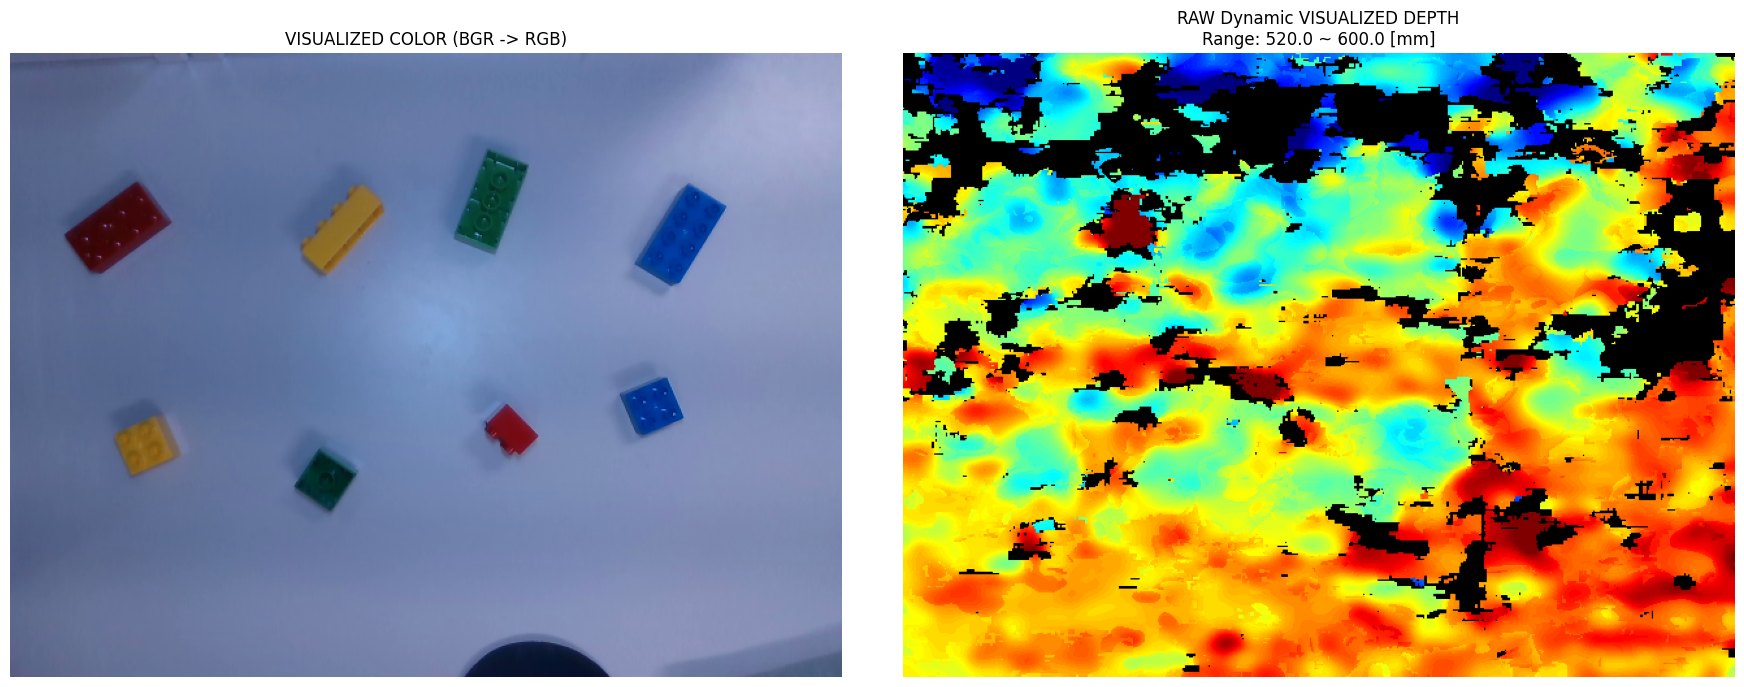

In [136]:
# ---------------------------------------------------------
# 카메라 원본 확인 + 전처리 누적 변수 초기화
# ---------------------------------------------------------

# 글로벌 변수 - 카메라 원본 이미지
    # color_img_bgr
    # depth_img

# 글로벌 변수 - 처리 완료된 각각의 컬러와 뎁스 저장
    # color_filtered
    # depth_filtered

# 전처리 누적 변수 초기화
color_filtered = color_img_bgr.copy()
depth_filtered = depth_img.copy()

color_filtered_before = color_filtered.copy()
color_filtered_after = color_filtered.copy()

depth_filtered_before = depth_filtered.copy()
depth_filtered_after = depth_filtered.copy()

valid_mask_filtered = (depth_filtered > 0).astype(np.uint8)

print("[INFO] 전처리 누적 변수 초기화 완료")
print(f"[INFO] color_filtered shape: {color_filtered.shape}")
print(f"[INFO] depth_filtered shape: {depth_filtered.shape}")
print(f"[INFO] valid depth pixels: {np.count_nonzero(valid_mask_filtered)}")


# ---------------------------------------------------------
# 카메라 원본 화면 확인
# ---------------------------------------------------------

# 비율에 맞춰서 이미지 비율 계산
width = 18
height = width * (3 / 8)
figsize = (width, height)

# 1행 2열 figsize에 맞춰서 설정
fig, axes = plt.subplots(1, 2, figsize=figsize)

# 컬러
vis_color_img = cv2.cvtColor(color_filtered, cv2.COLOR_BGR2RGB)
axes[0].imshow(vis_color_img)
axes[0].set_title("VISUALIZED COLOR (BGR -> RGB)")
axes[0].axis("off")

# 뎁스
vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered)
axes[1].imshow(vis_depth_img)
axes[1].set_title(
    f"RAW Dynamic VISUALIZED DEPTH\n"
    f"Range: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm]"
)
axes[1].axis("off")

# 시각화
plt.tight_layout()
plt.show()

### **IMAGE LOAD**

In [ ]:
# # ------------------------------------------------------------
# # 1. 이미 로드된 변수가 없거나 None이면 파일에서 로드
# # ------------------------------------------------------------
# if "depth_img" not in globals() or depth_img is None:
#     depth_img = cv2.imread(
#         "output/realsense_depth_filtered_aligned.png",
#         cv2.IMREAD_UNCHANGED
#     )

# if "color_img_bgr" not in globals() or color_img_bgr is None:
#     color_img_bgr = cv2.imread(
#         "output/realsense_color.png",
#         cv2.IMREAD_COLOR
#     )

# if depth_img is None:
#     raise FileNotFoundError("depth image를 읽지 못했습니다.")

# if color_img_bgr is None:
#     raise FileNotFoundError("color image를 읽지 못했습니다.")

# # ------------------------------------------------------------
# # 2. depth는 2D로 정리
# # ------------------------------------------------------------
# if depth_img.ndim == 3 and depth_img.shape[2] == 1:
#     depth_img = depth_img[:, :, 0]

# if depth_img.ndim != 2:
#     raise ValueError(f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}")

# # ------------------------------------------------------------
# # 4. color는 3채널 유지
# # ------------------------------------------------------------
# if color_img_bgr.ndim != 3 or color_img_bgr.shape[2] != 3:
#     raise ValueError(f"color_img_bgr는 HxWx3 컬러 이미지여야 합니다. 현재 shape: {color_img_bgr.shape}")

# # ------------------------------------------------------------
# # 5. 정보 출력
# # ------------------------------------------------------------
# print("depth:", type(depth_img), depth_img.shape, depth_img.dtype, depth_img.min(), depth_img.max())
# print("color:", type(color_img_bgr), color_img_bgr.shape, color_img_bgr.dtype, color_img_bgr.min(), color_img_bgr.max())

depth: <class 'numpy.ndarray'> (480, 640) uint16 0 645
color: <class 'numpy.ndarray'> (480, 640, 3) uint8 0 255


In [ ]:
# VISUALIZE_COLOR_AND_DEPTH(color_img_bgr, depth_img)

<hr style="height: 10px; background-color: #39FF14; border: none;">

# **전처리 시작**
<hr style="height: 5px; background-color: #39FF14; border: none;">

In [99]:
### 시각화 대비용 함수
def compare_depth(color_filtered, depth_filtered_before, depth_filtered_after):
    # 글로벌 변수 - 카메라 원본 이미지
        # color_img_bgr
        # depth_img

    # 글로벌 변수 - 처리 완료된 각각의 컬러와 뎁스 저장
        # color_filtered
        # depth_filtered

    # 비율에 맞춰서 이미지 비율 계산
    width = 18
    height = width * (3 / 8)
    figsize = (width, height)

    # 1행 3열 figsize에 맞춰서 설정
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # 컬러
    vis_color_img = cv2.cvtColor(color_filtered, cv2.COLOR_BGR2RGB)
    axes[0].imshow(vis_color_img)
    axes[0].set_title("VISUALIZED COLOR (BGR -> RGB)")
    axes[0].axis("off")

    # 뎁스 비포
    vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered_before)
    axes[1].imshow(vis_depth_img)
    axes[1].set_title(
        f"Dynamic VISUALIZED DEPTH [before]\n"
        f"Range: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm]"
    )
    axes[1].axis("off")

    # 뎁스 애프터
    vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered_after)
    axes[2].imshow(vis_depth_img)
    axes[2].set_title(
        f"Dynamic VISUALIZED DEPTH [after]\n"
        f"Range: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm]"
    )
    axes[2].axis("off")

    # 시각화
    plt.tight_layout()
    plt.show()


def compare_color(color_filtered_before, color_filtered_after, depth_filtered):
    # 글로벌 변수 - 카메라 원본 이미지
        # color_img_bgr
        # depth_img

    # 글로벌 변수 - 처리 완료된 각각의 컬러와 뎁스 저장
        # color_filtered
        # depth_filtered

    # 비율에 맞춰서 이미지 비율 계산
    width = 18
    height = width * (3 / 8)
    figsize = (width, height)

    # 1행 3열 figsize에 맞춰서 설정
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # 컬러 비포
    vis_color_img = cv2.cvtColor(color_filtered_before, cv2.COLOR_BGR2RGB)
    axes[0].imshow(vis_color_img)
    axes[0].set_title("VISUALIZED COLOR [before] (BGR -> RGB)")
    axes[0].axis("off")

    # 컬러 애프터
    vis_color_img = cv2.cvtColor(color_filtered_after, cv2.COLOR_BGR2RGB)
    axes[1].imshow(vis_color_img)
    axes[1].set_title("VISUALIZED COLOR [after] (BGR -> RGB)")
    axes[1].axis("off")

    # 뎁스
    vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered)
    axes[2].imshow(vis_depth_img)
    axes[2].set_title(
        f"Dynamic VISUALIZED DEPTH\n"
        f"Range: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm]"
    )
    axes[2].axis("off")

    # 시각화
    plt.tight_layout()
    plt.show()

```
depth_filtered = 누적 확정본
depth_filtered_before = 이번 처리 전
depth_filtered_after = 이번 처리 후
시각화 후 depth_filtered = depth_filtered_after.copy()
```

```
color_img_bgr / depth_img
→ 카메라 원본. 절대 안 건드림.

color_filtered / depth_filtered
→ 현재까지 전처리가 확정된 누적 결과.

color_filtered_before / depth_filtered_before
→ 이번 전처리 전 상태.

color_filtered_after / depth_filtered_after
→ 이번 전처리 후 상태.
```

## **Intrinsics / Depth → Point Cloud**

In [137]:
def get_intrinsics_values(intrinsics):
    """
    intrinsics dict에서 fx, fy, cx, cy, depth_scale을 추출한다.

    Returns
    -------
    fx, fy, cx, cy : float
        카메라 내부 파라미터.

    depth_to_mm_scale : float
        depth raw 값을 mm로 변환하는 scale.
    """

    if intrinsics is None:
        raise ValueError("intrinsics가 None입니다.")

    if isinstance(intrinsics, dict):
        if "color & depth" in intrinsics:
            intr = intrinsics["color & depth"]
        else:
            intr = intrinsics

        fx = float(intr["fx"])
        fy = float(intr["fy"])
        cx = float(intr["cx"])
        cy = float(intr["cy"])
        depth_scale = float(intr.get("depth_scale", 0.001))
        depth_to_mm_scale = depth_scale * 1000.0

    else:
        fx = float(intrinsics.fx)
        fy = float(intrinsics.fy)
        cx = float(intrinsics.ppx)
        cy = float(intrinsics.ppy)
        depth_to_mm_scale = 1.0

    return fx, fy, cx, cy, depth_to_mm_scale


def depth_mask_to_point_cloud_mm(
    depth_img,
    intrinsics,
    mask=None,
    sample_stride=1
):
    """
    depth image와 mask를 이용해 camera frame 기준 point cloud를 생성한다.
    단위는 mm.

    Parameters
    ----------
    depth_img : np.ndarray
        2D depth image.

    intrinsics : dict
        카메라 내부 파라미터.

    mask : np.ndarray or None
        사용할 영역 mask. None이면 depth > 0 전체 사용.

    sample_stride : int
        다운샘플링 stride.

    Returns
    -------
    points_mm : np.ndarray
        shape = (N, 3), [x, y, z], 단위 mm.

    pixels_uv : np.ndarray
        shape = (N, 2), [u, v].

    info : dict
        처리 정보.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if not isinstance(depth_img, np.ndarray):
        raise TypeError("depth_img는 np.ndarray 형식이어야 합니다.")

    if depth_img.ndim != 2:
        raise ValueError(f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}")

    if sample_stride is None or sample_stride <= 0:
        raise ValueError("sample_stride는 1 이상의 정수여야 합니다.")

    h, w = depth_img.shape

    if mask is None:
        valid_bool = depth_img > 0
    else:
        if mask.shape != depth_img.shape:
            raise ValueError("mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (mask > 0) & (depth_img > 0)

    stride_bool = np.zeros_like(valid_bool, dtype=bool)
    stride_bool[::sample_stride, ::sample_stride] = True
    valid_bool = valid_bool & stride_bool

    v_idx, u_idx = np.where(valid_bool)

    fx, fy, cx, cy, depth_to_mm_scale = get_intrinsics_values(intrinsics)

    depth_mm = depth_img[v_idx, u_idx].astype(np.float32) * depth_to_mm_scale

    x_mm = (u_idx.astype(np.float32) - cx) * depth_mm / fx
    y_mm = (v_idx.astype(np.float32) - cy) * depth_mm / fy
    z_mm = depth_mm

    points_mm = np.stack([x_mm, y_mm, z_mm], axis=1)
    pixels_uv = np.stack([u_idx, v_idx], axis=1)

    info = {
        "function": "depth_mask_to_point_cloud_mm",
        "image_shape": [int(h), int(w)],
        "sample_stride": int(sample_stride),
        "num_points": int(points_mm.shape[0]),
        "depth_to_mm_scale": float(depth_to_mm_scale),
    }

    return points_mm, pixels_uv, info

In [138]:
def run_yolo_segmentation_detections(
    color_img_bgr,
    model_path="manip_segmentor_0528.pt",
    conf_threshold=0.25
):
    """
    YOLOv8 segmentation 모델을 실행하여 detection list를 반환한다.

    Returns
    -------
    detections : list[dict]
        각 detection은 bbox, mask, class_id, class_name, confidence를 가진다.

    info : dict
        검출 정보.
    """

    if color_img_bgr is None:
        raise ValueError("color_img_bgr가 None입니다.")

    if not isinstance(color_img_bgr, np.ndarray):
        raise TypeError("color_img_bgr는 np.ndarray 형식이어야 합니다.")

    if color_img_bgr.ndim != 3:
        raise ValueError(f"color_img_bgr는 3D 컬러 이미지여야 합니다. 현재 shape: {color_img_bgr.shape}")

    try:
        from ultralytics import YOLO
    except ImportError:
        raise ImportError("ultralytics가 필요합니다. pip install ultralytics 후 실행하세요.")

    h, w = color_img_bgr.shape[:2]

    model = YOLO(model_path)

    results = model.predict(
        source=color_img_bgr,
        conf=conf_threshold,
        verbose=False
    )

    detections = []

    if len(results) == 0:
        info = {
            "function": "run_yolo_segmentation_detections",
            "model_path": model_path,
            "status": "NO_RESULT",
            "num_detections": 0,
        }
        return detections, info

    result = results[0]
    names = result.names

    if result.boxes is None or len(result.boxes) == 0:
        info = {
            "function": "run_yolo_segmentation_detections",
            "model_path": model_path,
            "status": "NO_BOX",
            "num_detections": 0,
        }
        return detections, info

    boxes = result.boxes

    has_mask = result.masks is not None
    masks = result.masks.data.cpu().numpy() if has_mask else None

    for i in range(len(boxes)):
        conf = float(boxes.conf[i].item())

        if conf < conf_threshold:
            continue

        cls_id = int(boxes.cls[i].item())
        class_name = names.get(cls_id, str(cls_id))

        xyxy = boxes.xyxy[i].cpu().numpy().astype(float)
        x1, y1, x2, y2 = xyxy.tolist()

        if has_mask:
            mask_small = masks[i]
            mask_resized = cv2.resize(
                mask_small.astype(np.float32),
                (w, h),
                interpolation=cv2.INTER_NEAREST
            )
            mask_u8 = (mask_resized > 0.5).astype(np.uint8)
        else:
            mask_u8 = np.zeros((h, w), dtype=np.uint8)
            mask_u8[int(y1):int(y2), int(x1):int(x2)] = 1

        det = {
            "index": int(i),
            "class_id": int(cls_id),
            "class_name": str(class_name),
            "confidence": float(conf),
            "bbox_xyxy": [float(x1), float(y1), float(x2), float(y2)],
            "mask": mask_u8,
            "mask_pixels": int(np.count_nonzero(mask_u8)),
        }

        detections.append(det)

    info = {
        "function": "run_yolo_segmentation_detections",
        "model_path": model_path,
        "status": "OK" if len(detections) > 0 else "NO_SELECTED_DETECTION",
        "conf_threshold": float(conf_threshold),
        "num_detections": int(len(detections)),
        "class_names": names,
    }

    return detections, info

In [139]:
def create_square_roi_from_bbox(
    bbox_xyxy,
    image_shape,
    padding_ratio=0.35,
    min_size=80
):
    """
    YOLO bbox를 기준으로 padding된 정사각형 ROI mask를 만든다.

    Parameters
    ----------
    bbox_xyxy : list
        [x1, y1, x2, y2]

    image_shape : tuple
        depth 또는 color image shape. (H, W) 또는 (H, W, C)

    padding_ratio : float
        bbox 크기 기준 padding 비율.

    min_size : int
        최소 정사각형 ROI 크기.

    Returns
    -------
    roi_mask : np.ndarray
        ROI mask. 0 또는 1.

    roi_info : dict
        ROI 정보.
    """

    if bbox_xyxy is None:
        raise ValueError("bbox_xyxy가 None입니다.")

    h, w = image_shape[:2]

    x1, y1, x2, y2 = bbox_xyxy

    bbox_w = float(x2 - x1)
    bbox_h = float(y2 - y1)

    if bbox_w <= 0 or bbox_h <= 0:
        raise ValueError(f"bbox 크기가 비정상입니다. bbox={bbox_xyxy}")

    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0

    side = max(bbox_w, bbox_h)
    side = side * (1.0 + 2.0 * float(padding_ratio))
    side = max(side, float(min_size))

    rx1 = int(round(cx - side / 2.0))
    ry1 = int(round(cy - side / 2.0))
    rx2 = int(round(cx + side / 2.0))
    ry2 = int(round(cy + side / 2.0))

    rx1 = max(0, rx1)
    ry1 = max(0, ry1)
    rx2 = min(w - 1, rx2)
    ry2 = min(h - 1, ry2)

    roi_mask = np.zeros((h, w), dtype=np.uint8)
    roi_mask[ry1:ry2 + 1, rx1:rx2 + 1] = 1

    roi_info = {
        "function": "create_square_roi_from_bbox",
        "bbox_xyxy": [float(x1), float(y1), float(x2), float(y2)],
        "padding_ratio": float(padding_ratio),
        "min_size": int(min_size),
        "roi_xyxy": [int(rx1), int(ry1), int(rx2), int(ry2)],
        "roi_width": int(rx2 - rx1 + 1),
        "roi_height": int(ry2 - ry1 + 1),
        "roi_pixels": int(np.count_nonzero(roi_mask)),
    }

    return roi_mask, roi_info

In [140]:
def fit_plane_ransac_o3d(
    points_mm,
    distance_threshold_mm=5.0,
    ransac_n=3,
    num_iterations=1000,
    orient_normal_to_camera=True
):
    """
    point cloud에서 Open3D RANSAC으로 plane을 추정한다.

    Returns
    -------
    plane_model : dict
        normal, d, equation 포함.

    inlier_indices : np.ndarray
        plane inlier index.

    info : dict
        RANSAC 정보.
    """

    if points_mm is None:
        raise ValueError("points_mm가 None입니다.")

    if not isinstance(points_mm, np.ndarray):
        raise TypeError("points_mm는 np.ndarray 형식이어야 합니다.")

    if points_mm.ndim != 2 or points_mm.shape[1] != 3:
        raise ValueError(f"points_mm는 (N, 3) 형태여야 합니다. 현재 shape: {points_mm.shape}")

    if points_mm.shape[0] < 50:
        raise ValueError(f"RANSAC에 사용할 point가 너무 적습니다. num_points={points_mm.shape[0]}")

    try:
        import open3d as o3d
    except ImportError:
        raise ImportError("open3d가 필요합니다.")

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_mm.astype(np.float64))

    raw_plane, inliers = pcd.segment_plane(
        distance_threshold=float(distance_threshold_mm),
        ransac_n=int(ransac_n),
        num_iterations=int(num_iterations)
    )

    a, b, c, d = [float(v) for v in raw_plane]

    normal = np.array([a, b, c], dtype=np.float64)
    normal_norm = np.linalg.norm(normal)

    if normal_norm <= 1e-9:
        raise ValueError("plane normal norm이 비정상입니다.")

    normal = normal / normal_norm
    d = d / normal_norm

    inlier_indices = np.asarray(inliers, dtype=np.int64)
    inlier_points = points_mm[inlier_indices]

    plane_center = np.mean(inlier_points, axis=0)

    if orient_normal_to_camera:
        camera_origin = np.array([0.0, 0.0, 0.0], dtype=np.float64)
        camera_side_vec = camera_origin - plane_center

        if np.dot(normal, camera_side_vec) < 0:
            normal = -normal
            d = -d

    distances = points_mm @ normal + d
    inlier_distances = distances[inlier_indices]

    plane_model = {
        "normal": normal,
        "d": float(d),
        "a": float(normal[0]),
        "b": float(normal[1]),
        "c": float(normal[2]),
        "equation": "ax + by + cz + d = 0",
        "plane_center": plane_center,
    }

    info = {
        "function": "fit_plane_ransac_o3d",
        "num_points": int(points_mm.shape[0]),
        "num_inliers": int(len(inlier_indices)),
        "inlier_ratio": float(len(inlier_indices) / max(points_mm.shape[0], 1)),
        "distance_threshold_mm": float(distance_threshold_mm),
        "ransac_n": int(ransac_n),
        "num_iterations": int(num_iterations),
        "mean_abs_inlier_distance_mm": float(np.mean(np.abs(inlier_distances))) if inlier_distances.size > 0 else None,
        "normal": [float(normal[0]), float(normal[1]), float(normal[2])],
        "d": float(d),
        "plane_center": [float(v) for v in plane_center],
    }

    return plane_model, inlier_indices, info

In [141]:
def compute_height_map_from_plane(
    depth_img,
    intrinsics,
    plane_model,
    valid_mask=None
):
    """
    plane model 기준 signed height map을 생성한다.

    Parameters
    ----------
    depth_img : np.ndarray
        depth image.

    intrinsics : dict
        카메라 내부 파라미터.

    plane_model : dict
        fit_plane_ransac_o3d에서 반환된 plane_model.

    valid_mask : np.ndarray or None
        유효 mask.

    Returns
    -------
    height_map : np.ndarray
        plane 기준 signed height map. 단위 mm.

    height_valid_mask : np.ndarray
        valid mask.

    info : dict
        통계 정보.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if plane_model is None:
        raise ValueError("plane_model이 None입니다.")

    h, w = depth_img.shape

    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    normal = np.asarray(plane_model["normal"], dtype=np.float64)
    d = float(plane_model["d"])

    points_mm, pixels_uv, pc_info = depth_mask_to_point_cloud_mm(
        depth_img=depth_img,
        intrinsics=intrinsics,
        mask=valid_bool.astype(np.uint8),
        sample_stride=1
    )

    signed_height = points_mm.astype(np.float64) @ normal + d

    height_map = np.zeros((h, w), dtype=np.float32)

    u = pixels_uv[:, 0]
    v = pixels_uv[:, 1]

    height_map[v, u] = signed_height.astype(np.float32)

    height_valid_mask = valid_bool.astype(np.uint8)

    valid_values = height_map[height_valid_mask > 0]

    info = {
        "function": "compute_height_map_from_plane",
        "height_min_mm": float(np.min(valid_values)) if valid_values.size > 0 else None,
        "height_max_mm": float(np.max(valid_values)) if valid_values.size > 0 else None,
        "height_mean_mm": float(np.mean(valid_values)) if valid_values.size > 0 else None,
        "height_std_mm": float(np.std(valid_values)) if valid_values.size > 0 else None,
        "num_valid": int(np.count_nonzero(height_valid_mask)),
        "pointcloud_info": pc_info,
    }

    return height_map, height_valid_mask, info

In [142]:
def create_2d_convex_hull_mask(
    input_mask,
    min_points=10
):
    """
    binary mask의 foreground pixel을 기준으로 2D convex hull mask를 생성한다.

    Parameters
    ----------
    input_mask : np.ndarray
        입력 binary mask. 0 또는 1.

    min_points : int
        hull 계산 최소 점 수.

    Returns
    -------
    hull_mask : np.ndarray
        convex hull로 채워진 mask. 0 또는 1.

    hull_info : dict
        hull 정보.
    """

    if input_mask is None:
        raise ValueError("input_mask가 None입니다.")

    if input_mask.ndim != 2:
        raise ValueError(f"input_mask는 2D mask여야 합니다. 현재 shape: {input_mask.shape}")

    mask_u8 = (input_mask > 0).astype(np.uint8)

    ys, xs = np.where(mask_u8 > 0)

    hull_mask = np.zeros_like(mask_u8, dtype=np.uint8)

    if len(xs) < min_points:
        hull_info = {
            "function": "create_2d_convex_hull_mask",
            "status": "NOT_ENOUGH_POINTS",
            "input_pixels": int(np.count_nonzero(mask_u8)),
            "hull_pixels": 0,
            "min_points": int(min_points),
        }
        return hull_mask, hull_info

    points = np.stack([xs, ys], axis=1).astype(np.int32)

    hull = cv2.convexHull(points)

    cv2.fillConvexPoly(hull_mask, hull, 1)

    hull_info = {
        "function": "create_2d_convex_hull_mask",
        "status": "OK",
        "input_pixels": int(np.count_nonzero(mask_u8)),
        "hull_pixels": int(np.count_nonzero(hull_mask)),
        "added_pixels": int(np.count_nonzero(hull_mask) - np.count_nonzero(mask_u8)),
        "min_points": int(min_points),
    }

    return hull_mask, hull_info

In [143]:
def create_center_region_mask_from_bbox(
    bbox_xyxy,
    image_shape,
    center_ratio=0.45
):
    """
    bbox 중앙부 영역 mask를 생성한다.

    Returns
    -------
    center_mask : np.ndarray
        bbox 중앙부 mask.

    info : dict
        처리 정보.
    """

    if bbox_xyxy is None:
        raise ValueError("bbox_xyxy가 None입니다.")

    h, w = image_shape[:2]

    x1, y1, x2, y2 = bbox_xyxy

    bw = float(x2 - x1)
    bh = float(y2 - y1)

    if bw <= 0 or bh <= 0:
        raise ValueError("bbox 크기가 비정상입니다.")

    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0

    cw = bw * float(center_ratio)
    ch = bh * float(center_ratio)

    rx1 = int(round(cx - cw / 2.0))
    ry1 = int(round(cy - ch / 2.0))
    rx2 = int(round(cx + cw / 2.0))
    ry2 = int(round(cy + ch / 2.0))

    rx1 = max(0, rx1)
    ry1 = max(0, ry1)
    rx2 = min(w - 1, rx2)
    ry2 = min(h - 1, ry2)

    center_mask = np.zeros((h, w), dtype=np.uint8)
    center_mask[ry1:ry2 + 1, rx1:rx2 + 1] = 1

    info = {
        "function": "create_center_region_mask_from_bbox",
        "bbox_xyxy": [float(v) for v in bbox_xyxy],
        "center_ratio": float(center_ratio),
        "center_xyxy": [int(rx1), int(ry1), int(rx2), int(ry2)],
        "center_pixels": int(np.count_nonzero(center_mask)),
    }

    return center_mask, info

In [144]:
def analyze_local_face_by_hull_and_plane(
    depth_img,
    intrinsics,
    floor_plane_model,
    yolo_mask,
    hull_mask,
    center_mask,
    sample_stride=1,
    local_plane_distance_threshold_mm=3.0
):
    """
    YOLO mask, convex hull mask, center mask를 기준으로
    로컬 평면과 floor 기준 height를 비교한다.

    목적
    ----
    - YOLO mask 원본 영역의 height
    - convex hull 영역의 height
    - 중앙부 height
    - YOLO mask local plane
    - hull mask local plane

    을 비교해서 top / side / back 후보 판단에 사용할 수 있는 수치를 만든다.

    Returns
    -------
    face_info : dict
        면 판단용 정보.
    """

    if yolo_mask is None:
        raise ValueError("yolo_mask가 None입니다.")

    if hull_mask is None:
        raise ValueError("hull_mask가 None입니다.")

    if center_mask is None:
        raise ValueError("center_mask가 None입니다.")

    if yolo_mask.shape != depth_img.shape:
        raise ValueError("yolo_mask와 depth_img의 shape가 다릅니다.")

    if hull_mask.shape != depth_img.shape:
        raise ValueError("hull_mask와 depth_img의 shape가 다릅니다.")

    if center_mask.shape != depth_img.shape:
        raise ValueError("center_mask와 depth_img의 shape가 다릅니다.")

    # floor 기준 height map
    height_map, height_valid_mask, height_info = compute_height_map_from_plane(
        depth_img=depth_img,
        intrinsics=intrinsics,
        plane_model=floor_plane_model,
        valid_mask=(depth_img > 0).astype(np.uint8)
    )

    yolo_valid = (yolo_mask > 0) & (height_valid_mask > 0)
    hull_valid = (hull_mask > 0) & (height_valid_mask > 0)
    center_valid = (center_mask > 0) & (height_valid_mask > 0)
    center_yolo_valid = center_valid & (yolo_mask > 0)
    center_hull_valid = center_valid & (hull_mask > 0)

    def safe_stats(values):
        if values.size == 0:
            return {
                "count": 0,
                "median": None,
                "mean": None,
                "std": None,
                "min": None,
                "max": None,
            }

        return {
            "count": int(values.size),
            "median": float(np.median(values)),
            "mean": float(np.mean(values)),
            "std": float(np.std(values)),
            "min": float(np.min(values)),
            "max": float(np.max(values)),
        }

    yolo_h = height_map[yolo_valid]
    hull_h = height_map[hull_valid]
    center_yolo_h = height_map[center_yolo_valid]
    center_hull_h = height_map[center_hull_valid]

    yolo_stats = safe_stats(yolo_h)
    hull_stats = safe_stats(hull_h)
    center_yolo_stats = safe_stats(center_yolo_h)
    center_hull_stats = safe_stats(center_hull_h)

    # height 차이
    if yolo_stats["median"] is not None and hull_stats["median"] is not None:
        hull_minus_yolo_median = float(hull_stats["median"] - yolo_stats["median"])
    else:
        hull_minus_yolo_median = None

    if center_yolo_stats["median"] is not None and center_hull_stats["median"] is not None:
        center_hull_minus_yolo_median = float(center_hull_stats["median"] - center_yolo_stats["median"])
    else:
        center_hull_minus_yolo_median = None

    # YOLO 원본 mask local plane
    yolo_points, _, yolo_pc_info = depth_mask_to_point_cloud_mm(
        depth_img=depth_img,
        intrinsics=intrinsics,
        mask=yolo_mask,
        sample_stride=sample_stride
    )

    hull_points, _, hull_pc_info = depth_mask_to_point_cloud_mm(
        depth_img=depth_img,
        intrinsics=intrinsics,
        mask=hull_mask,
        sample_stride=sample_stride
    )

    yolo_plane_info = None
    hull_plane_info = None

    yolo_plane_model = None
    hull_plane_model = None

    if yolo_points.shape[0] >= 50:
        yolo_plane_model, _, yolo_plane_info = fit_plane_ransac_o3d(
            points_mm=yolo_points,
            distance_threshold_mm=local_plane_distance_threshold_mm,
            ransac_n=3,
            num_iterations=500,
            orient_normal_to_camera=True
        )

    if hull_points.shape[0] >= 50:
        hull_plane_model, _, hull_plane_info = fit_plane_ransac_o3d(
            points_mm=hull_points,
            distance_threshold_mm=local_plane_distance_threshold_mm,
            ransac_n=3,
            num_iterations=500,
            orient_normal_to_camera=True
        )

    # local plane center의 floor 기준 height
    def plane_center_height(local_plane_model):
        if local_plane_model is None:
            return None

        center = np.asarray(local_plane_model["plane_center"], dtype=np.float64)
        floor_n = np.asarray(floor_plane_model["normal"], dtype=np.float64)
        floor_d = float(floor_plane_model["d"])

        return float(center @ floor_n + floor_d)

    yolo_plane_height = plane_center_height(yolo_plane_model)
    hull_plane_height = plane_center_height(hull_plane_model)

    if yolo_plane_height is not None and hull_plane_height is not None:
        hull_plane_minus_yolo_plane_height = float(hull_plane_height - yolo_plane_height)
    else:
        hull_plane_minus_yolo_plane_height = None

    # 매우 단순한 후보 판단 v0
    # 나중에 데이터 보고 threshold는 조정
    face_candidate = "UNKNOWN"

    if hull_plane_minus_yolo_plane_height is not None:
        diff_abs = abs(hull_plane_minus_yolo_plane_height)

        if diff_abs <= 3.0:
            face_candidate = "SIDE_CANDIDATE"
        elif 3.0 < diff_abs <= 8.0:
            face_candidate = "TOP_CANDIDATE"
        elif diff_abs > 8.0:
            face_candidate = "BACK_OR_BOTTOM_CANDIDATE"

    face_info = {
        "function": "analyze_local_face_by_hull_and_plane",
        "face_candidate_v0": face_candidate,

        "yolo_height_stats": yolo_stats,
        "hull_height_stats": hull_stats,
        "center_yolo_height_stats": center_yolo_stats,
        "center_hull_height_stats": center_hull_stats,

        "hull_minus_yolo_median_height_mm": hull_minus_yolo_median,
        "center_hull_minus_yolo_median_height_mm": center_hull_minus_yolo_median,

        "yolo_plane_height_from_floor_mm": yolo_plane_height,
        "hull_plane_height_from_floor_mm": hull_plane_height,
        "hull_plane_minus_yolo_plane_height_mm": hull_plane_minus_yolo_plane_height,

        "yolo_pointcloud_info": yolo_pc_info,
        "hull_pointcloud_info": hull_pc_info,

        "yolo_plane_info": yolo_plane_info,
        "hull_plane_info": hull_plane_info,

        "height_map_info": height_info,
    }

    return face_info, height_map, height_valid_mask

In [145]:
def visualize_yolo_roi_hull_analysis(
    color_img_bgr,
    roi_mask=None,
    yolo_mask=None,
    hull_mask=None,
    center_mask=None
):
    """
    YOLO ROI / YOLO mask / convex hull / center mask를 비교 시각화한다.
    """

    if color_img_bgr is None:
        raise ValueError("color_img_bgr가 None입니다.")

    color_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

    items = []

    if roi_mask is not None:
        items.append(("ROI MASK", roi_mask))

    if yolo_mask is not None:
        items.append(("YOLO MASK", yolo_mask))

    if hull_mask is not None:
        items.append(("CONVEX HULL MASK", hull_mask))

    if center_mask is not None:
        items.append(("CENTER MASK", center_mask))

    fig, axes = plt.subplots(1, len(items) + 1, figsize=(5 * (len(items) + 1), 5))

    axes[0].imshow(color_rgb)
    axes[0].set_title("COLOR")
    axes[0].axis("off")

    for i, (title, mask) in enumerate(items):
        overlay = color_rgb.copy()
        mask_bool = mask > 0

        overlay[mask_bool] = (
            overlay[mask_bool] * 0.55 +
            np.array([255, 0, 0]) * 0.45
        ).astype(np.uint8)

        axes[i + 1].imshow(overlay)
        axes[i + 1].set_title(f"{title}\nPixels: {np.count_nonzero(mask)}")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()

In [146]:
def visualize_yolo_roi_hull_analysis(
    color_img_bgr,
    roi_mask=None,
    yolo_mask=None,
    hull_mask=None,
    center_mask=None
):
    """
    YOLO ROI / YOLO mask / convex hull / center mask를 비교 시각화한다.
    """

    if color_img_bgr is None:
        raise ValueError("color_img_bgr가 None입니다.")

    color_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

    items = []

    if roi_mask is not None:
        items.append(("ROI MASK", roi_mask))

    if yolo_mask is not None:
        items.append(("YOLO MASK", yolo_mask))

    if hull_mask is not None:
        items.append(("CONVEX HULL MASK", hull_mask))

    if center_mask is not None:
        items.append(("CENTER MASK", center_mask))

    fig, axes = plt.subplots(1, len(items) + 1, figsize=(5 * (len(items) + 1), 5))

    axes[0].imshow(color_rgb)
    axes[0].set_title("COLOR")
    axes[0].axis("off")

    for i, (title, mask) in enumerate(items):
        overlay = color_rgb.copy()
        mask_bool = mask > 0

        overlay[mask_bool] = (
            overlay[mask_bool] * 0.55 +
            np.array([255, 0, 0]) * 0.45
        ).astype(np.uint8)

        axes[i + 1].imshow(overlay)
        axes[i + 1].set_title(f"{title}\nPixels: {np.count_nonzero(mask)}")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()

In [147]:
# ---------------------------------------------------------
# YOLO Segmentation Detection 실행부
# ---------------------------------------------------------

yolo_model_path = "manip_segmentor_0528.pt"

detections, yolo_info = run_yolo_segmentation_detections(
    color_img_bgr=color_filtered,
    model_path=yolo_model_path,
    conf_threshold=0.25
)

print("\n[YOLO Detection 결과 통계]")
pprint.pprint(yolo_info, sort_dicts=False)

for det in detections:
    print(
        f"[DET {det['index']}] "
        f"class={det['class_name']} "
        f"conf={det['confidence']:.3f} "
        f"bbox={det['bbox_xyxy']} "
        f"mask_pixels={det['mask_pixels']}"
    )


[YOLO Detection 결과 통계]
{'function': 'run_yolo_segmentation_detections',
 'model_path': 'manip_segmentor_0528.pt',
 'status': 'OK',
 'conf_threshold': 0.25,
 'num_detections': 8,
 'class_names': {0: '2x2_blue',
                 1: '2x2_green',
                 2: '2x2_orange',
                 3: '2x2_red',
                 4: '2x2_yellow',
                 5: '4x2_blue',
                 6: '4x2_green',
                 7: '4x2_orange',
                 8: '4x2_red',
                 9: '4x2_yellow'}}
[DET 0] class=4x2_yellow conf=0.993 bbox=[225.02810668945312, 100.978515625, 287.7189025878906, 169.501708984375] mask_pixels=2169
[DET 1] class=2x2_yellow conf=0.988 bbox=[80.39845275878906, 278.25408935546875, 129.98277282714844, 323.86663818359375] mask_pixels=1619
[DET 2] class=4x2_red conf=0.978 bbox=[41.57197570800781, 98.37348175048828, 124.61300659179688, 168.89849853515625] mask_pixels=3094
[DET 3] class=2x2_red conf=0.969 bbox=[366.06561279296875, 269.30963134765625, 407.337524

In [148]:
# ---------------------------------------------------------
# 사용할 YOLO detection 선택
# ---------------------------------------------------------

if len(detections) == 0:
    raise RuntimeError("YOLO detection이 없습니다.")

areas = [det["mask_pixels"] for det in detections]
selected_idx = int(np.argmax(areas))

selected_det = detections[selected_idx]

selected_bbox = selected_det["bbox_xyxy"]
selected_yolo_mask = selected_det["mask"].astype(np.uint8)

print("\n[Selected Detection]")
pprint.pprint({
    "selected_idx": selected_idx,
    "class_name": selected_det["class_name"],
    "confidence": selected_det["confidence"],
    "bbox_xyxy": selected_bbox,
    "mask_pixels": int(np.count_nonzero(selected_yolo_mask)),
}, sort_dicts=False)


[Selected Detection]
{'selected_idx': 2,
 'class_name': '4x2_red',
 'confidence': 0.9777477383613586,
 'bbox_xyxy': [41.57197570800781,
               98.37348175048828,
               124.61300659179688,
               168.89849853515625],
 'mask_pixels': 3094}


In [149]:
# ---------------------------------------------------------
# YOLO bbox 기준 Square ROI 생성
# ---------------------------------------------------------

roi_mask, roi_info = create_square_roi_from_bbox(
    bbox_xyxy=selected_bbox,
    image_shape=depth_filtered.shape,
    padding_ratio=0.35,
    min_size=100
)

print("\n[Square ROI 결과 통계]")
pprint.pprint(roi_info, sort_dicts=False)


[Square ROI 결과 통계]
{'function': 'create_square_roi_from_bbox',
 'bbox_xyxy': [41.57197570800781,
               98.37348175048828,
               124.61300659179688,
               168.89849853515625],
 'padding_ratio': 0.35,
 'min_size': 100,
 'roi_xyxy': [13, 63, 154, 204],
 'roi_width': 142,
 'roi_height': 142,
 'roi_pixels': 20164}


In [150]:
# ---------------------------------------------------------
# ROI 영역 기준 Floor RANSAC 실행부
# ---------------------------------------------------------

roi_points, roi_pixels, roi_pc_info = depth_mask_to_point_cloud_mm(
    depth_img=depth_filtered,
    intrinsics=intrinsics,
    mask=roi_mask,
    sample_stride=2
)

print("\n[ROI Point Cloud 결과 통계]")
pprint.pprint(roi_pc_info, sort_dicts=False)

floor_plane_model, floor_inliers, floor_ransac_info = fit_plane_ransac_o3d(
    points_mm=roi_points,
    distance_threshold_mm=5.0,
    ransac_n=3,
    num_iterations=1000,
    orient_normal_to_camera=True
)

print("\n[ROI Floor RANSAC 결과 통계]")
pprint.pprint(floor_ransac_info, sort_dicts=False)


[ROI Point Cloud 결과 통계]
{'function': 'depth_mask_to_point_cloud_mm',
 'image_shape': [480, 640],
 'sample_stride': 2,
 'num_points': 3663,
 'depth_to_mm_scale': 1.0000000474974513}

[ROI Floor RANSAC 결과 통계]
{'function': 'fit_plane_ransac_o3d',
 'num_points': 3663,
 'num_inliers': 2181,
 'inlier_ratio': 0.5954135954135954,
 'distance_threshold_mm': 5.0,
 'ransac_n': 3,
 'num_iterations': 1000,
 'mean_abs_inlier_distance_mm': 2.2087478789633956,
 'normal': [-0.05595969665478086, 0.14696539875369738, -0.9875574332257703],
 'd': 551.5698779229274,
 'plane_center': [-226.8524627685547, -88.74908447265625, 558.1664428710938]}


In [151]:
# ---------------------------------------------------------
# YOLO Mask / Convex Hull / Center Mask 생성
# ---------------------------------------------------------

# ROI 밖은 비활성화
selected_yolo_mask_roi = ((selected_yolo_mask > 0) & (roi_mask > 0)).astype(np.uint8)

hull_mask, hull_info = create_2d_convex_hull_mask(
    input_mask=selected_yolo_mask_roi,
    min_points=10
)

center_mask, center_info = create_center_region_mask_from_bbox(
    bbox_xyxy=selected_bbox,
    image_shape=depth_filtered.shape,
    center_ratio=0.45
)

center_mask = ((center_mask > 0) & (roi_mask > 0)).astype(np.uint8)

print("\n[Convex Hull 결과 통계]")
pprint.pprint(hull_info, sort_dicts=False)

print("\n[Center Mask 결과 통계]")
pprint.pprint(center_info, sort_dicts=False)


[Convex Hull 결과 통계]
{'function': 'create_2d_convex_hull_mask',
 'status': 'OK',
 'input_pixels': 3094,
 'hull_pixels': 3321,
 'added_pixels': 227,
 'min_points': 10}

[Center Mask 결과 통계]
{'function': 'create_center_region_mask_from_bbox',
 'bbox_xyxy': [41.57197570800781,
               98.37348175048828,
               124.61300659179688,
               168.89849853515625],
 'center_ratio': 0.45,
 'center_xyxy': [64, 118, 102, 150],
 'center_pixels': 1287}


In [152]:
# ---------------------------------------------------------
# Local Face 분석 실행부
# ---------------------------------------------------------

face_info, floor_height_map, floor_height_valid_mask = analyze_local_face_by_hull_and_plane(
    depth_img=depth_filtered,
    intrinsics=intrinsics,
    floor_plane_model=floor_plane_model,
    yolo_mask=selected_yolo_mask_roi,
    hull_mask=hull_mask,
    center_mask=center_mask,
    sample_stride=1,
    local_plane_distance_threshold_mm=3.0
)

print("\n[Local Face 분석 결과]")
pprint.pprint(face_info, sort_dicts=False)


[Local Face 분석 결과]
{'function': 'analyze_local_face_by_hull_and_plane',
 'face_candidate_v0': 'SIDE_CANDIDATE',
 'yolo_height_stats': {'count': 3094,
                       'median': 1.0296001434326172,
                       'mean': 1.0535842180252075,
                       'std': 4.279991149902344,
                       'min': -11.029571533203125,
                       'max': 10.770835876464844},
 'hull_height_stats': {'count': 3321,
                       'median': 0.8228389024734497,
                       'mean': 0.87845778465271,
                       'std': 4.295413017272949,
                       'min': -11.029571533203125,
                       'max': 10.770835876464844},
 'center_yolo_height_stats': {'count': 1260,
                              'median': 3.121455192565918,
                              'mean': 3.240879535675049,
                              'std': 3.8041741847991943,
                              'min': -4.468986988067627,
                            

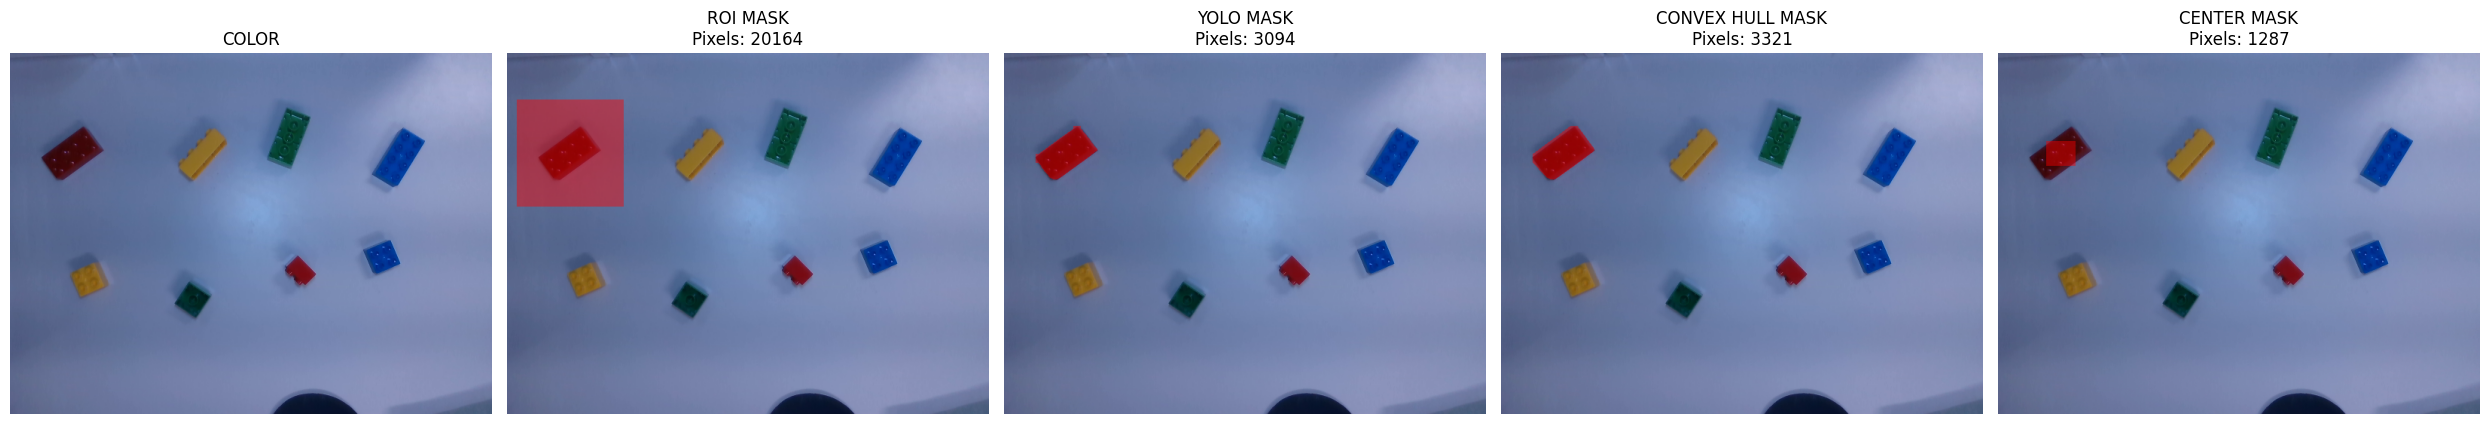

In [153]:
# ---------------------------------------------------------
# YOLO / ROI / Convex Hull / Center Mask 시각화
# ---------------------------------------------------------

visualize_yolo_roi_hull_analysis(
    color_img_bgr=color_filtered,
    roi_mask=roi_mask,
    yolo_mask=selected_yolo_mask_roi,
    hull_mask=hull_mask,
    center_mask=center_mask
)

<hr style="height: 5px; background-color: #39FF14; border: none;">

In [154]:
def create_local_plane_residual_map(
    depth_img,
    intrinsics,
    local_mask,
    local_plane_model=None,
    sample_stride=1,
    distance_threshold_mm=3.0,
    num_iterations=500
):
    """
    local_mask 내부 point cloud에 대해 local plane을 추정하고,
    각 pixel이 local plane에서 얼마나 떨어져 있는지 residual map을 생성한다.

    residual 의미
    -------------
    residual = point · normal + d

    normal은 카메라 방향을 향하도록 정리되어 있으므로,
    부호 해석은 실제 결과를 보고 조정한다.

    Parameters
    ----------
    depth_img : np.ndarray
        depth image.

    intrinsics : dict
        카메라 내부 파라미터.

    local_mask : np.ndarray
        YOLO mask 또는 분석 대상 mask.

    local_plane_model : dict or None
        이미 계산된 local plane이 있으면 사용.
        None이면 local_mask point cloud로 RANSAC plane 추정.

    sample_stride : int
        RANSAC용 point cloud stride.

    distance_threshold_mm : float
        local plane RANSAC threshold.

    num_iterations : int
        RANSAC 반복 횟수.

    Returns
    -------
    residual_map : np.ndarray
        local plane residual map. 단위 mm. invalid는 0.

    residual_valid_mask : np.ndarray
        residual 계산 가능 mask. 0 또는 1.

    local_plane_model : dict
        추정된 local plane model.

    info : dict
        residual 통계.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if local_mask is None:
        raise ValueError("local_mask가 None입니다.")

    if depth_img.ndim != 2:
        raise ValueError(f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}")

    if local_mask.shape != depth_img.shape:
        raise ValueError("local_mask와 depth_img의 shape가 다릅니다.")

    h, w = depth_img.shape

    valid_mask = ((local_mask > 0) & (depth_img > 0)).astype(np.uint8)

    points_mm, pixels_uv, pc_info = depth_mask_to_point_cloud_mm(
        depth_img=depth_img,
        intrinsics=intrinsics,
        mask=valid_mask,
        sample_stride=sample_stride
    )

    if points_mm.shape[0] < 50:
        raise ValueError(f"local plane 분석 point가 너무 적습니다. num_points={points_mm.shape[0]}")

    if local_plane_model is None:
        local_plane_model, inliers, plane_info = fit_plane_ransac_o3d(
            points_mm=points_mm,
            distance_threshold_mm=distance_threshold_mm,
            ransac_n=3,
            num_iterations=num_iterations,
            orient_normal_to_camera=True
        )
    else:
        inliers = None
        plane_info = {
            "function": "given_local_plane_model",
            "num_points": int(points_mm.shape[0])
        }

    normal = np.asarray(local_plane_model["normal"], dtype=np.float64)
    d = float(local_plane_model["d"])

    residual = points_mm.astype(np.float64) @ normal + d

    residual_map = np.zeros((h, w), dtype=np.float32)

    u = pixels_uv[:, 0]
    v = pixels_uv[:, 1]

    residual_map[v, u] = residual.astype(np.float32)

    residual_valid_mask = valid_mask.copy()

    residual_values = residual_map[residual_valid_mask > 0]

    info = {
        "function": "create_local_plane_residual_map",
        "num_points": int(points_mm.shape[0]),
        "distance_threshold_mm": float(distance_threshold_mm),
        "num_iterations": int(num_iterations),

        "residual_median_mm": float(np.median(residual_values)) if residual_values.size > 0 else None,
        "residual_mean_mm": float(np.mean(residual_values)) if residual_values.size > 0 else None,
        "residual_std_mm": float(np.std(residual_values)) if residual_values.size > 0 else None,
        "residual_min_mm": float(np.min(residual_values)) if residual_values.size > 0 else None,
        "residual_max_mm": float(np.max(residual_values)) if residual_values.size > 0 else None,

        "pointcloud_info": pc_info,
        "plane_info": plane_info,
    }

    return residual_map, residual_valid_mask, local_plane_model, info

In [155]:
def create_residual_feature_masks(
    residual_map,
    residual_valid_mask,
    protrusion_threshold_mm=3.0,
    depression_threshold_mm=-3.0,
    morph_kernel=3,
    min_area=20
):
    """
    local plane residual map에서 돌출/함몰 영역을 분리한다.

    Parameters
    ----------
    residual_map : np.ndarray
        local plane residual map.

    residual_valid_mask : np.ndarray
        residual valid mask.

    protrusion_threshold_mm : float
        이 값보다 큰 residual을 protrusion 후보로 본다.

    depression_threshold_mm : float
        이 값보다 작은 residual을 depression 후보로 본다.

    morph_kernel : int
        morphology kernel size.

    min_area : int
        작은 component 제거 기준.

    Returns
    -------
    protrusion_mask : np.ndarray
        돌출 후보 mask.

    depression_mask : np.ndarray
        함몰 후보 mask.

    info : dict
        처리 정보.
    """

    if residual_map is None:
        raise ValueError("residual_map이 None입니다.")

    if residual_valid_mask is None:
        raise ValueError("residual_valid_mask가 None입니다.")

    if residual_map.shape != residual_valid_mask.shape:
        raise ValueError("residual_map과 residual_valid_mask의 shape가 다릅니다.")

    valid_bool = residual_valid_mask > 0

    protrusion_mask = ((residual_map >= protrusion_threshold_mm) & valid_bool).astype(np.uint8)
    depression_mask = ((residual_map <= depression_threshold_mm) & valid_bool).astype(np.uint8)

    if morph_kernel is not None and morph_kernel > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (morph_kernel, morph_kernel)
        )

        protrusion_mask = cv2.morphologyEx(protrusion_mask, cv2.MORPH_OPEN, kernel)
        protrusion_mask = cv2.morphologyEx(protrusion_mask, cv2.MORPH_CLOSE, kernel)

        depression_mask = cv2.morphologyEx(depression_mask, cv2.MORPH_OPEN, kernel)
        depression_mask = cv2.morphologyEx(depression_mask, cv2.MORPH_CLOSE, kernel)

    def remove_small_components(mask, min_area):
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )

        cleaned = np.zeros_like(mask, dtype=np.uint8)
        kept = 0
        areas = []

        for label_id in range(1, num_labels):
            area = stats[label_id, cv2.CC_STAT_AREA]

            if area >= min_area:
                cleaned[labels == label_id] = 1
                kept += 1
                areas.append(int(area))

        return cleaned, kept, areas

    protrusion_mask, protrusion_components, protrusion_areas = remove_small_components(
        protrusion_mask,
        min_area=min_area
    )

    depression_mask, depression_components, depression_areas = remove_small_components(
        depression_mask,
        min_area=min_area
    )

    info = {
        "function": "create_residual_feature_masks",
        "protrusion_threshold_mm": float(protrusion_threshold_mm),
        "depression_threshold_mm": float(depression_threshold_mm),
        "morph_kernel": int(morph_kernel) if morph_kernel is not None else None,
        "min_area": int(min_area),

        "protrusion_pixels": int(np.count_nonzero(protrusion_mask)),
        "depression_pixels": int(np.count_nonzero(depression_mask)),

        "protrusion_components": int(protrusion_components),
        "depression_components": int(depression_components),

        "protrusion_areas": protrusion_areas,
        "depression_areas": depression_areas,
    }

    return protrusion_mask, depression_mask, info

In [156]:
# ---------------------------------------------------------
# Local Plane Residual 분석 실행부
# ---------------------------------------------------------

residual_map, residual_valid_mask, local_plane_model, residual_info = create_local_plane_residual_map(
    depth_img=depth_filtered,
    intrinsics=intrinsics,
    local_mask=selected_yolo_mask_roi,
    local_plane_model=None,
    sample_stride=1,
    distance_threshold_mm=3.0,
    num_iterations=500
)

print("\n[Local Plane Residual 결과 통계]")
pprint.pprint(residual_info, sort_dicts=False)


[Local Plane Residual 결과 통계]
{'function': 'create_local_plane_residual_map',
 'num_points': 3094,
 'distance_threshold_mm': 3.0,
 'num_iterations': 500,
 'residual_median_mm': -0.003458826569840312,
 'residual_mean_mm': 0.29553544521331787,
 'residual_std_mm': 4.517787933349609,
 'residual_min_mm': -12.259705543518066,
 'residual_max_mm': 11.711904525756836,
 'pointcloud_info': {'function': 'depth_mask_to_point_cloud_mm',
                     'image_shape': [480, 640],
                     'sample_stride': 1,
                     'num_points': 3094,
                     'depth_to_mm_scale': 1.0000000474974513},
 'plane_info': {'function': 'fit_plane_ransac_o3d',
                'num_points': 3094,
                'num_inliers': 1883,
                'inlier_ratio': 0.6085972850678733,
                'distance_threshold_mm': 3.0,
                'ransac_n': 3,
                'num_iterations': 500,
                'mean_abs_inlier_distance_mm': 1.2548350365117806,
                'nor

In [157]:
# ---------------------------------------------------------
# Residual Feature Mask 실행부
# ---------------------------------------------------------

protrusion_mask, depression_mask, residual_feature_info = create_residual_feature_masks(
    residual_map=residual_map,
    residual_valid_mask=residual_valid_mask,
    protrusion_threshold_mm=3.0,
    depression_threshold_mm=-3.0,
    morph_kernel=3,
    min_area=20
)

print("\n[Residual Feature Mask 결과 통계]")
pprint.pprint(residual_feature_info, sort_dicts=False)


[Residual Feature Mask 결과 통계]
{'function': 'create_residual_feature_masks',
 'protrusion_threshold_mm': 3.0,
 'depression_threshold_mm': -3.0,
 'morph_kernel': 3,
 'min_area': 20,
 'protrusion_pixels': 599,
 'depression_pixels': 466,
 'protrusion_components': 2,
 'depression_components': 2,
 'protrusion_areas': [553, 46],
 'depression_areas': [224, 242]}


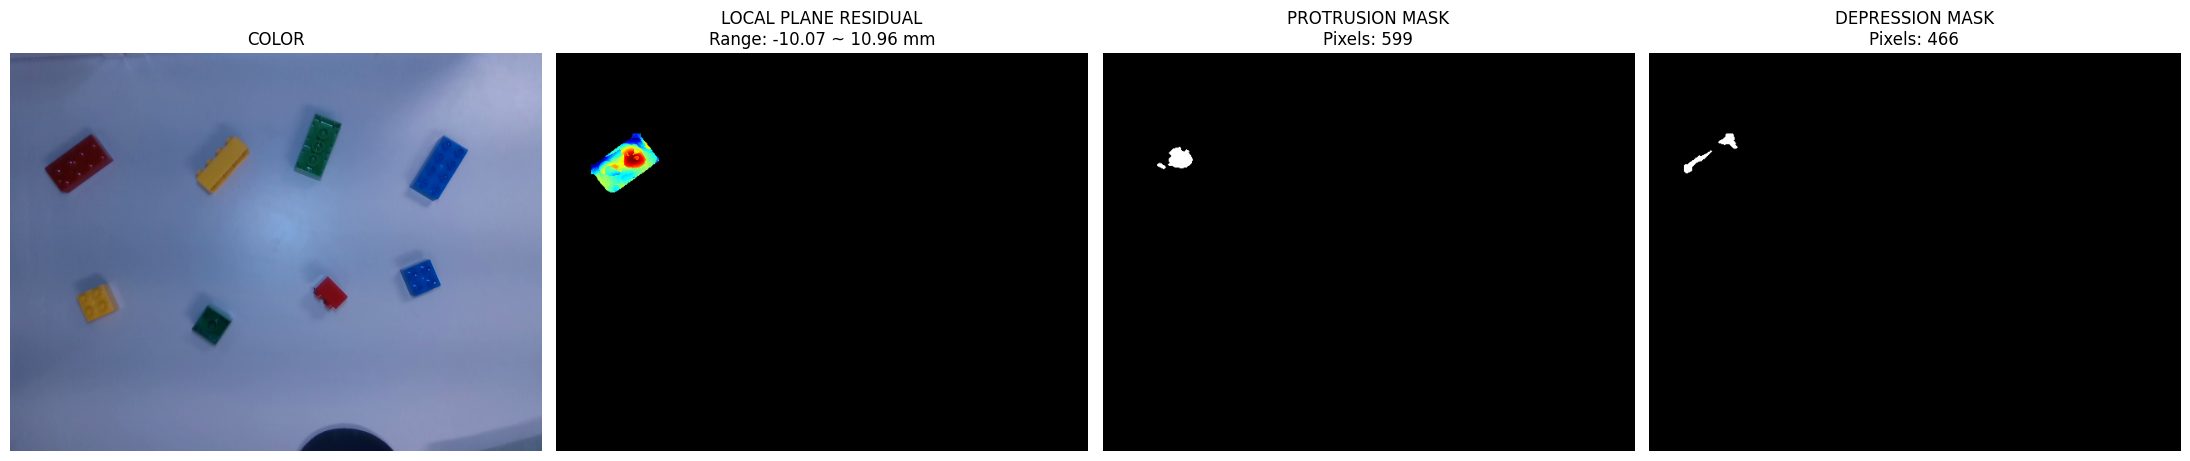

In [158]:
# ---------------------------------------------------------
# Residual / Protrusion / Depression 시각화
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

color_rgb = cv2.cvtColor(color_filtered, cv2.COLOR_BGR2RGB)

axes[0].imshow(color_rgb)
axes[0].set_title("COLOR")
axes[0].axis("off")

# residual 시각화
res_vis = residual_map.copy()
res_valid = residual_valid_mask > 0

if np.count_nonzero(res_valid) > 0:
    r_min = np.percentile(res_vis[res_valid], 1)
    r_max = np.percentile(res_vis[res_valid], 99)

    if r_max <= r_min:
        r_max = r_min + 1.0

    res_clip = np.clip(res_vis, r_min, r_max)

    res_norm = np.zeros_like(res_vis, dtype=np.uint8)
    res_norm[res_valid] = (
        (res_clip[res_valid] - r_min) / (r_max - r_min) * 255
    ).astype(np.uint8)

    res_color = cv2.applyColorMap(res_norm, cv2.COLORMAP_JET)
    res_color[~res_valid] = (0, 0, 0)
    res_color = cv2.cvtColor(res_color, cv2.COLOR_BGR2RGB)

    axes[1].imshow(res_color)
    axes[1].set_title(f"LOCAL PLANE RESIDUAL\nRange: {r_min:.2f} ~ {r_max:.2f} mm")
else:
    axes[1].imshow(np.zeros_like(residual_map), cmap="gray")
    axes[1].set_title("LOCAL PLANE RESIDUAL EMPTY")

axes[1].axis("off")

axes[2].imshow(protrusion_mask, cmap="gray")
axes[2].set_title(f"PROTRUSION MASK\nPixels: {np.count_nonzero(protrusion_mask)}")
axes[2].axis("off")

axes[3].imshow(depression_mask, cmap="gray")
axes[3].set_title(f"DEPRESSION MASK\nPixels: {np.count_nonzero(depression_mask)}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

<hr style="height: 5px; background-color: #39FF14; border: none;">

In [160]:
def create_top_candidate_mask_from_height(
    yolo_mask,
    height_map,
    height_valid_mask,
    mode="hybrid",
    height_percentile=70.0,
    max_drop_mm=6.0,
    min_height_mm=5.0,
    morph_kernel=3,
    min_area=50
):
    """
    YOLO mask 내부에서 floor 기준 height가 높은 영역만 추출하여
    top candidate mask를 생성한다.

    목적
    ----
    YOLO mask 전체에는 윗면, 옆면, edge, depth noise가 섞일 수 있으므로,
    floor 기준 height가 높은 부분만 골라 local top plane RANSAC에 사용한다.

    Parameters
    ----------
    yolo_mask : np.ndarray
        YOLO segmentation mask. 0 또는 1.

    height_map : np.ndarray
        floor plane 기준 signed height map. 단위 mm.

    height_valid_mask : np.ndarray
        height valid mask. 0 또는 1.

    mode : str
        "percentile", "max_drop", "hybrid" 중 하나.
        percentile : YOLO mask 내부 height percentile 이상 사용.
        max_drop   : max_height - max_drop_mm 이상 사용.
        hybrid     : 두 threshold 중 더 높은 값을 사용.

    height_percentile : float
        percentile mode에서 사용할 percentile.

    max_drop_mm : float
        max_drop mode에서 사용할 최대 높이 대비 허용 하강량.

    min_height_mm : float
        floor 기준 최소 height. 바닥 섞임 방지용.

    morph_kernel : int
        morphology kernel size. 0 또는 None이면 적용하지 않음.

    min_area : int
        작은 component 제거 기준.

    Returns
    -------
    top_candidate_mask : np.ndarray
        height 상위 band mask. 0 또는 1.

    info : dict
        처리 정보.
    """

    if yolo_mask is None:
        raise ValueError("yolo_mask가 None입니다.")

    if height_map is None:
        raise ValueError("height_map이 None입니다.")

    if height_valid_mask is None:
        raise ValueError("height_valid_mask가 None입니다.")

    if yolo_mask.shape != height_map.shape:
        raise ValueError("yolo_mask와 height_map의 shape가 다릅니다.")

    if height_valid_mask.shape != height_map.shape:
        raise ValueError("height_valid_mask와 height_map의 shape가 다릅니다.")

    if mode not in ["percentile", "max_drop", "hybrid"]:
        raise ValueError("mode는 'percentile', 'max_drop', 'hybrid' 중 하나여야 합니다.")

    yolo_valid = (yolo_mask > 0) & (height_valid_mask > 0)

    height_values = height_map[yolo_valid]

    if height_values.size == 0:
        raise ValueError("YOLO mask 내부에 valid height 값이 없습니다.")

    h_max = float(np.max(height_values))
    h_median = float(np.median(height_values))
    h_mean = float(np.mean(height_values))
    h_std = float(np.std(height_values))

    percentile_thr = float(np.percentile(height_values, height_percentile))
    max_drop_thr = float(h_max - max_drop_mm)

    if mode == "percentile":
        threshold = percentile_thr
    elif mode == "max_drop":
        threshold = max_drop_thr
    else:
        threshold = max(percentile_thr, max_drop_thr)

    threshold = max(threshold, float(min_height_mm))

    top_bool = (
        yolo_valid &
        (height_map >= threshold)
    )

    top_candidate_mask = top_bool.astype(np.uint8)

    if morph_kernel is not None and morph_kernel > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (morph_kernel, morph_kernel)
        )

        top_candidate_mask = cv2.morphologyEx(
            top_candidate_mask,
            cv2.MORPH_CLOSE,
            kernel
        )

        top_candidate_mask = cv2.morphologyEx(
            top_candidate_mask,
            cv2.MORPH_OPEN,
            kernel
        )

    # 작은 component 제거
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        top_candidate_mask,
        connectivity=8
    )

    cleaned_mask = np.zeros_like(top_candidate_mask, dtype=np.uint8)

    kept_components = 0
    kept_areas = []

    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]

        if area >= min_area:
            cleaned_mask[labels == label_id] = 1
            kept_components += 1
            kept_areas.append(int(area))

    info = {
        "function": "create_top_candidate_mask_from_height",
        "mode": str(mode),
        "height_percentile": float(height_percentile),
        "max_drop_mm": float(max_drop_mm),
        "min_height_mm": float(min_height_mm),
        "threshold_mm": float(threshold),

        "yolo_valid_pixels": int(np.count_nonzero(yolo_valid)),
        "top_pixels_before_area_filter": int(np.count_nonzero(top_candidate_mask)),
        "top_pixels_after_area_filter": int(np.count_nonzero(cleaned_mask)),

        "height_max_mm": h_max,
        "height_median_mm": h_median,
        "height_mean_mm": h_mean,
        "height_std_mm": h_std,
        "percentile_threshold_mm": percentile_thr,
        "max_drop_threshold_mm": max_drop_thr,

        "num_components_total": int(num_labels - 1),
        "num_components_kept": int(kept_components),
        "kept_areas": kept_areas,
    }

    return cleaned_mask, info

In [161]:
def clean_point_cloud_from_mask(
    depth_img,
    intrinsics,
    input_mask,
    sample_stride=1,
    nb_neighbors=20,
    std_ratio=2.0
):
    """
    input_mask 내부 depth point cloud를 생성한 뒤,
    Open3D Statistical Outlier Removal을 적용한다.

    Parameters
    ----------
    depth_img : np.ndarray
        depth image.

    intrinsics : dict
        카메라 내부 파라미터.

    input_mask : np.ndarray
        point cloud로 변환할 mask.

    sample_stride : int
        point cloud 생성 stride.

    nb_neighbors : int
        statistical outlier removal 이웃 개수.

    std_ratio : float
        statistical outlier removal threshold.

    Returns
    -------
    cleaned_points_mm : np.ndarray
        outlier 제거 후 point cloud.

    cleaned_pixels_uv : np.ndarray
        cleaned point에 대응되는 pixel 좌표 [u, v].

    cleaned_mask : np.ndarray
        cleaned point 위치를 다시 image mask로 표현한 것. 0 또는 1.

    info : dict
        처리 정보.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if input_mask is None:
        raise ValueError("input_mask가 None입니다.")

    if input_mask.shape != depth_img.shape:
        raise ValueError("input_mask와 depth_img의 shape가 다릅니다.")

    try:
        import open3d as o3d
    except ImportError:
        raise ImportError("open3d가 필요합니다.")

    points_mm, pixels_uv, pc_info = depth_mask_to_point_cloud_mm(
        depth_img=depth_img,
        intrinsics=intrinsics,
        mask=input_mask,
        sample_stride=sample_stride
    )

    if points_mm.shape[0] < nb_neighbors:
        cleaned_mask = np.zeros_like(input_mask, dtype=np.uint8)

        info = {
            "function": "clean_point_cloud_from_mask",
            "status": "NOT_ENOUGH_POINTS",
            "num_points_before": int(points_mm.shape[0]),
            "num_points_after": 0,
            "nb_neighbors": int(nb_neighbors),
            "std_ratio": float(std_ratio),
            "pointcloud_info": pc_info,
        }

        return points_mm, pixels_uv, cleaned_mask, info

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_mm.astype(np.float64))

    cleaned_pcd, inlier_indices = pcd.remove_statistical_outlier(
        nb_neighbors=int(nb_neighbors),
        std_ratio=float(std_ratio)
    )

    inlier_indices = np.asarray(inlier_indices, dtype=np.int64)

    cleaned_points_mm = points_mm[inlier_indices]
    cleaned_pixels_uv = pixels_uv[inlier_indices]

    cleaned_mask = np.zeros_like(input_mask, dtype=np.uint8)

    if cleaned_pixels_uv.shape[0] > 0:
        u = cleaned_pixels_uv[:, 0]
        v = cleaned_pixels_uv[:, 1]
        cleaned_mask[v, u] = 1

    info = {
        "function": "clean_point_cloud_from_mask",
        "status": "OK",
        "sample_stride": int(sample_stride),
        "nb_neighbors": int(nb_neighbors),
        "std_ratio": float(std_ratio),
        "num_points_before": int(points_mm.shape[0]),
        "num_points_after": int(cleaned_points_mm.shape[0]),
        "removed_points": int(points_mm.shape[0] - cleaned_points_mm.shape[0]),
        "removed_ratio": float((points_mm.shape[0] - cleaned_points_mm.shape[0]) / max(points_mm.shape[0], 1)),
        "cleaned_mask_pixels": int(np.count_nonzero(cleaned_mask)),
        "pointcloud_info": pc_info,
    }

    return cleaned_points_mm, cleaned_pixels_uv, cleaned_mask, info

In [162]:
def fit_local_plane_from_cleaned_points(
    cleaned_points_mm,
    distance_threshold_mm=2.0,
    ransac_n=3,
    num_iterations=1000
):
    """
    전처리된 point cloud에서 local plane을 RANSAC으로 추정한다.

    Returns
    -------
    local_plane_model : dict
        local plane model.

    local_inliers : np.ndarray
        inlier index.

    info : dict
        RANSAC 정보.
    """

    if cleaned_points_mm is None:
        raise ValueError("cleaned_points_mm가 None입니다.")

    if cleaned_points_mm.ndim != 2 or cleaned_points_mm.shape[1] != 3:
        raise ValueError(f"cleaned_points_mm는 (N, 3) 형태여야 합니다. 현재 shape: {cleaned_points_mm.shape}")

    if cleaned_points_mm.shape[0] < 50:
        raise ValueError(f"local plane RANSAC point가 너무 적습니다. num_points={cleaned_points_mm.shape[0]}")

    local_plane_model, local_inliers, local_ransac_info = fit_plane_ransac_o3d(
        points_mm=cleaned_points_mm,
        distance_threshold_mm=distance_threshold_mm,
        ransac_n=ransac_n,
        num_iterations=num_iterations,
        orient_normal_to_camera=True
    )

    info = {
        "function": "fit_local_plane_from_cleaned_points",
        "distance_threshold_mm": float(distance_threshold_mm),
        "ransac_n": int(ransac_n),
        "num_iterations": int(num_iterations),
        "local_ransac_info": local_ransac_info,
    }

    return local_plane_model, local_inliers, info

In [163]:
def compute_residual_map_with_given_plane(
    depth_img,
    intrinsics,
    target_mask,
    plane_model
):
    """
    주어진 plane_model을 기준으로 target_mask 내부 residual map을 계산한다.

    Parameters
    ----------
    depth_img : np.ndarray
        depth image.

    intrinsics : dict
        카메라 내부 파라미터.

    target_mask : np.ndarray
        residual을 계산할 영역 mask.

    plane_model : dict
        기준 plane model.

    Returns
    -------
    residual_map : np.ndarray
        plane 기준 residual map. 단위 mm.

    residual_valid_mask : np.ndarray
        residual valid mask.

    info : dict
        residual 통계.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if target_mask is None:
        raise ValueError("target_mask가 None입니다.")

    if plane_model is None:
        raise ValueError("plane_model이 None입니다.")

    if target_mask.shape != depth_img.shape:
        raise ValueError("target_mask와 depth_img의 shape가 다릅니다.")

    h, w = depth_img.shape

    points_mm, pixels_uv, pc_info = depth_mask_to_point_cloud_mm(
        depth_img=depth_img,
        intrinsics=intrinsics,
        mask=target_mask,
        sample_stride=1
    )

    if points_mm.shape[0] == 0:
        raise ValueError("residual 계산에 사용할 point가 없습니다.")

    normal = np.asarray(plane_model["normal"], dtype=np.float64)
    d = float(plane_model["d"])

    residual = points_mm.astype(np.float64) @ normal + d

    residual_map = np.zeros((h, w), dtype=np.float32)

    u = pixels_uv[:, 0]
    v = pixels_uv[:, 1]

    residual_map[v, u] = residual.astype(np.float32)

    residual_valid_mask = np.zeros((h, w), dtype=np.uint8)
    residual_valid_mask[v, u] = 1

    residual_values = residual_map[residual_valid_mask > 0]

    abs_values = np.abs(residual_values)

    info = {
        "function": "compute_residual_map_with_given_plane",
        "num_points": int(points_mm.shape[0]),

        "residual_median_mm": float(np.median(residual_values)) if residual_values.size > 0 else None,
        "residual_mean_mm": float(np.mean(residual_values)) if residual_values.size > 0 else None,
        "residual_std_mm": float(np.std(residual_values)) if residual_values.size > 0 else None,
        "residual_min_mm": float(np.min(residual_values)) if residual_values.size > 0 else None,
        "residual_max_mm": float(np.max(residual_values)) if residual_values.size > 0 else None,

        "abs_residual_median_mm": float(np.median(abs_values)) if abs_values.size > 0 else None,
        "abs_residual_mean_mm": float(np.mean(abs_values)) if abs_values.size > 0 else None,
        "abs_residual_std_mm": float(np.std(abs_values)) if abs_values.size > 0 else None,
        "abs_residual_max_mm": float(np.max(abs_values)) if abs_values.size > 0 else None,

        "pointcloud_info": pc_info,
    }

    return residual_map, residual_valid_mask, info

In [164]:
def create_abs_residual_feature_mask(
    residual_map,
    residual_valid_mask,
    abs_threshold_mm=3.0,
    morph_kernel=3,
    min_area=20
):
    """
    residual의 절댓값이 threshold 이상인 영역을 feature mask로 만든다.

    Parameters
    ----------
    residual_map : np.ndarray
        plane residual map.

    residual_valid_mask : np.ndarray
        residual valid mask.

    abs_threshold_mm : float
        abs(residual) threshold.

    morph_kernel : int
        morphology kernel size.

    min_area : int
        작은 component 제거 기준.

    Returns
    -------
    abs_feature_mask : np.ndarray
        abs residual feature mask.

    info : dict
        처리 정보.
    """

    if residual_map is None:
        raise ValueError("residual_map이 None입니다.")

    if residual_valid_mask is None:
        raise ValueError("residual_valid_mask가 None입니다.")

    if residual_map.shape != residual_valid_mask.shape:
        raise ValueError("residual_map과 residual_valid_mask의 shape가 다릅니다.")

    valid_bool = residual_valid_mask > 0

    abs_feature_mask = ((np.abs(residual_map) >= abs_threshold_mm) & valid_bool).astype(np.uint8)

    if morph_kernel is not None and morph_kernel > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (morph_kernel, morph_kernel)
        )

        abs_feature_mask = cv2.morphologyEx(abs_feature_mask, cv2.MORPH_OPEN, kernel)
        abs_feature_mask = cv2.morphologyEx(abs_feature_mask, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        abs_feature_mask,
        connectivity=8
    )

    cleaned_mask = np.zeros_like(abs_feature_mask, dtype=np.uint8)

    kept_components = 0
    kept_areas = []

    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]

        if area >= min_area:
            cleaned_mask[labels == label_id] = 1
            kept_components += 1
            kept_areas.append(int(area))

    info = {
        "function": "create_abs_residual_feature_mask",
        "abs_threshold_mm": float(abs_threshold_mm),
        "morph_kernel": int(morph_kernel) if morph_kernel is not None else None,
        "min_area": int(min_area),

        "feature_pixels_before_area_filter": int(np.count_nonzero(abs_feature_mask)),
        "feature_pixels_after_area_filter": int(np.count_nonzero(cleaned_mask)),
        "num_components_total": int(num_labels - 1),
        "num_components_kept": int(kept_components),
        "kept_areas": kept_areas,
    }

    return cleaned_mask, info

In [165]:
def visualize_top_candidate_and_residual(
    color_img_bgr,
    yolo_mask,
    top_candidate_mask,
    cleaned_top_mask,
    residual_map,
    residual_valid_mask,
    abs_feature_mask
):
    """
    YOLO mask, top candidate, point cloud cleaned mask, residual, abs feature를 시각화한다.
    """

    if color_img_bgr is None:
        raise ValueError("color_img_bgr가 None입니다.")

    color_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 6, figsize=(30, 5))

    axes[0].imshow(color_rgb)
    axes[0].set_title("COLOR")
    axes[0].axis("off")

    def overlay_mask(base_rgb, mask, alpha=0.45):
        overlay = base_rgb.copy()
        mask_bool = mask > 0
        overlay[mask_bool] = (
            overlay[mask_bool] * (1.0 - alpha) +
            np.array([255, 0, 0]) * alpha
        ).astype(np.uint8)
        return overlay

    axes[1].imshow(overlay_mask(color_rgb, yolo_mask))
    axes[1].set_title(f"YOLO MASK\nPixels: {np.count_nonzero(yolo_mask)}")
    axes[1].axis("off")

    axes[2].imshow(overlay_mask(color_rgb, top_candidate_mask))
    axes[2].set_title(f"TOP CANDIDATE\nPixels: {np.count_nonzero(top_candidate_mask)}")
    axes[2].axis("off")

    axes[3].imshow(overlay_mask(color_rgb, cleaned_top_mask))
    axes[3].set_title(f"CLEANED TOP PC MASK\nPixels: {np.count_nonzero(cleaned_top_mask)}")
    axes[3].axis("off")

    # residual 시각화
    res_valid = residual_valid_mask > 0

    if np.count_nonzero(res_valid) > 0:
        r_min = np.percentile(residual_map[res_valid], 1)
        r_max = np.percentile(residual_map[res_valid], 99)

        if r_max <= r_min:
            r_max = r_min + 1.0

        res_clip = np.clip(residual_map, r_min, r_max)

        res_norm = np.zeros_like(residual_map, dtype=np.uint8)
        res_norm[res_valid] = (
            (res_clip[res_valid] - r_min) / (r_max - r_min) * 255
        ).astype(np.uint8)

        res_color = cv2.applyColorMap(res_norm, cv2.COLORMAP_JET)
        res_color[~res_valid] = (0, 0, 0)
        res_color = cv2.cvtColor(res_color, cv2.COLOR_BGR2RGB)

        axes[4].imshow(res_color)
        axes[4].set_title(f"RESIDUAL FROM TOP PLANE\nRange: {r_min:.2f} ~ {r_max:.2f} mm")
    else:
        axes[4].imshow(np.zeros_like(residual_map), cmap="gray")
        axes[4].set_title("RESIDUAL EMPTY")

    axes[4].axis("off")

    axes[5].imshow(abs_feature_mask, cmap="gray")
    axes[5].set_title(f"ABS RESIDUAL FEATURE\nPixels: {np.count_nonzero(abs_feature_mask)}")
    axes[5].axis("off")

    plt.tight_layout()
    plt.show()

In [166]:
# ---------------------------------------------------------
# Top Candidate Mask 실행부
# ---------------------------------------------------------

top_candidate_mask, top_candidate_info = create_top_candidate_mask_from_height(
    yolo_mask=selected_yolo_mask_roi,
    height_map=floor_height_map,
    height_valid_mask=floor_height_valid_mask,
    mode="hybrid",
    height_percentile=70.0,
    max_drop_mm=6.0,
    min_height_mm=5.0,
    morph_kernel=3,
    min_area=50
)

print("\n[Top Candidate Mask 결과 통계]")
pprint.pprint(top_candidate_info, sort_dicts=False)


[Top Candidate Mask 결과 통계]
{'function': 'create_top_candidate_mask_from_height',
 'mode': 'hybrid',
 'height_percentile': 70.0,
 'max_drop_mm': 6.0,
 'min_height_mm': 5.0,
 'threshold_mm': 5.0,
 'yolo_valid_pixels': 3094,
 'top_pixels_before_area_filter': 551,
 'top_pixels_after_area_filter': 478,
 'height_max_mm': 10.770835876464844,
 'height_median_mm': 1.0296001434326172,
 'height_mean_mm': 1.0535842180252075,
 'height_std_mm': 4.279991149902344,
 'percentile_threshold_mm': 3.435964703559874,
 'max_drop_threshold_mm': 4.770835876464844,
 'num_components_total': 4,
 'num_components_kept': 2,
 'kept_areas': [416, 62]}


In [167]:
# ---------------------------------------------------------
# Top Candidate Point Cloud 전처리 실행부
# ---------------------------------------------------------

cleaned_top_points_mm, cleaned_top_pixels_uv, cleaned_top_mask, top_pc_clean_info = clean_point_cloud_from_mask(
    depth_img=depth_filtered,
    intrinsics=intrinsics,
    input_mask=top_candidate_mask,
    sample_stride=1,
    nb_neighbors=20,
    std_ratio=2.0
)

print("\n[Top Candidate Point Cloud Cleaning 결과 통계]")
pprint.pprint(top_pc_clean_info, sort_dicts=False)


[Top Candidate Point Cloud Cleaning 결과 통계]
{'function': 'clean_point_cloud_from_mask',
 'status': 'OK',
 'sample_stride': 1,
 'nb_neighbors': 20,
 'std_ratio': 2.0,
 'num_points_before': 478,
 'num_points_after': 456,
 'removed_points': 22,
 'removed_ratio': 0.04602510460251046,
 'cleaned_mask_pixels': 456,
 'pointcloud_info': {'function': 'depth_mask_to_point_cloud_mm',
                     'image_shape': [480, 640],
                     'sample_stride': 1,
                     'num_points': 478,
                     'depth_to_mm_scale': 1.0000000474974513}}


In [168]:
# ---------------------------------------------------------
# Top Local Plane RANSAC 실행부
# ---------------------------------------------------------

top_plane_model, top_plane_inliers, top_plane_info = fit_local_plane_from_cleaned_points(
    cleaned_points_mm=cleaned_top_points_mm,
    distance_threshold_mm=2.0,
    ransac_n=3,
    num_iterations=1000
)

print("\n[Top Local Plane RANSAC 결과 통계]")
pprint.pprint(top_plane_info, sort_dicts=False)


[Top Local Plane RANSAC 결과 통계]
{'function': 'fit_local_plane_from_cleaned_points',
 'distance_threshold_mm': 2.0,
 'ransac_n': 3,
 'num_iterations': 1000,
 'local_ransac_info': {'function': 'fit_plane_ransac_o3d',
                       'num_points': 456,
                       'num_inliers': 330,
                       'inlier_ratio': 0.7236842105263158,
                       'distance_threshold_mm': 2.0,
                       'ransac_n': 3,
                       'num_iterations': 1000,
                       'mean_abs_inlier_distance_mm': 0.9396824670098516,
                       'normal': [-0.019487183577619523,
                                  0.28141697644311026,
                                  -0.9593876875621399],
                       'd': 550.4624019696463,
                       'plane_center': [-218.0578155517578,
                                        -103.72909545898438,
                                        547.7666625976562]}}


In [169]:
# ---------------------------------------------------------
# Top Plane 기준 YOLO Mask Residual 실행부
# ---------------------------------------------------------

top_residual_map, top_residual_valid_mask, top_residual_info = compute_residual_map_with_given_plane(
    depth_img=depth_filtered,
    intrinsics=intrinsics,
    target_mask=selected_yolo_mask_roi,
    plane_model=top_plane_model
)

print("\n[Top Plane Residual 결과 통계]")
pprint.pprint(top_residual_info, sort_dicts=False)


[Top Plane Residual 결과 통계]
{'function': 'compute_residual_map_with_given_plane',
 'num_points': 3094,
 'residual_median_mm': -6.078867435455322,
 'residual_mean_mm': -6.582032680511475,
 'residual_std_mm': 4.970554828643799,
 'residual_min_mm': -22.115175247192383,
 'residual_max_mm': 2.9133503437042236,
 'abs_residual_median_mm': 6.078867435455322,
 'abs_residual_mean_mm': 6.749511241912842,
 'abs_residual_std_mm': 4.740639686584473,
 'abs_residual_max_mm': 22.115175247192383,
 'pointcloud_info': {'function': 'depth_mask_to_point_cloud_mm',
                     'image_shape': [480, 640],
                     'sample_stride': 1,
                     'num_points': 3094,
                     'depth_to_mm_scale': 1.0000000474974513}}


In [170]:
# ---------------------------------------------------------
# Abs Residual Feature Mask 실행부
# ---------------------------------------------------------

abs_feature_mask, abs_feature_info = create_abs_residual_feature_mask(
    residual_map=top_residual_map,
    residual_valid_mask=top_residual_valid_mask,
    abs_threshold_mm=3.0,
    morph_kernel=3,
    min_area=20
)

print("\n[Abs Residual Feature Mask 결과 통계]")
pprint.pprint(abs_feature_info, sort_dicts=False)


[Abs Residual Feature Mask 결과 통계]
{'function': 'create_abs_residual_feature_mask',
 'abs_threshold_mm': 3.0,
 'morph_kernel': 3,
 'min_area': 20,
 'feature_pixels_before_area_filter': 2306,
 'feature_pixels_after_area_filter': 2306,
 'num_components_total': 1,
 'num_components_kept': 1,
 'kept_areas': [2306]}


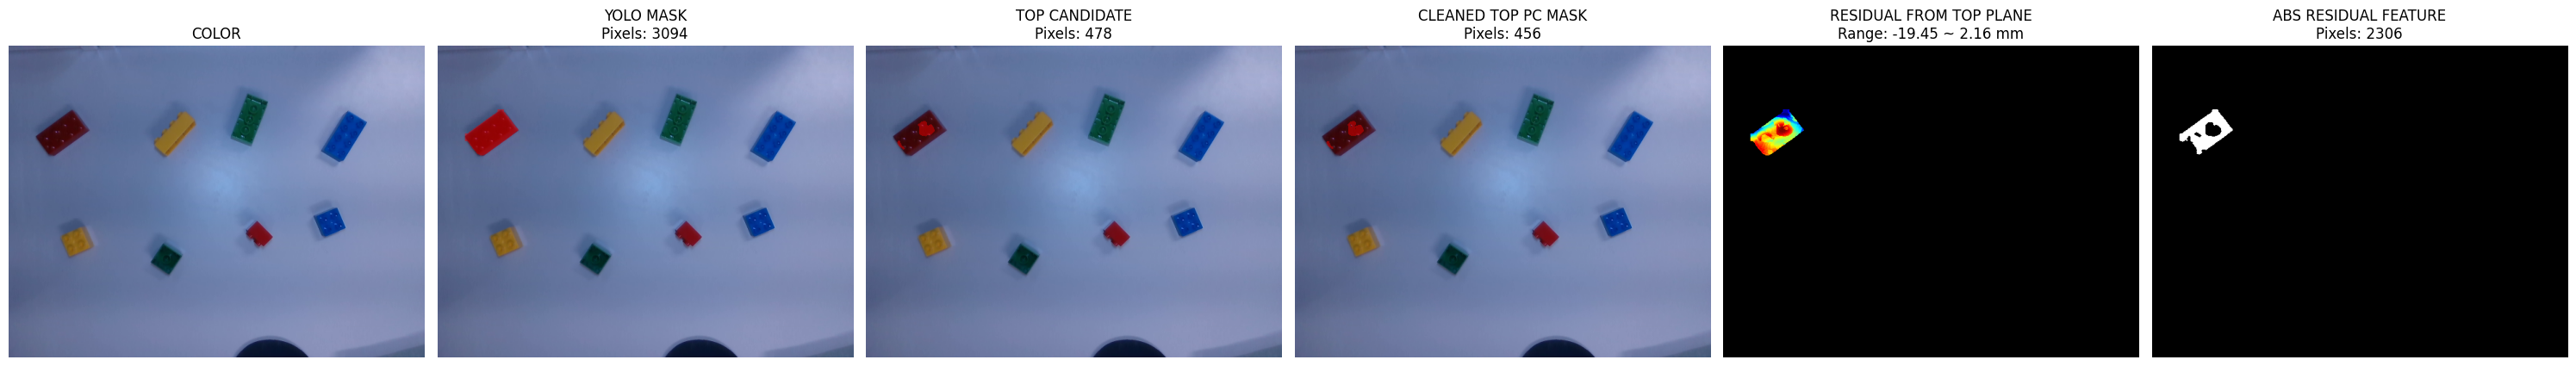

In [171]:
# ---------------------------------------------------------
# Top Candidate / Residual 시각화
# ---------------------------------------------------------

visualize_top_candidate_and_residual(
    color_img_bgr=color_filtered,
    yolo_mask=selected_yolo_mask_roi,
    top_candidate_mask=top_candidate_mask,
    cleaned_top_mask=cleaned_top_mask,
    residual_map=top_residual_map,
    residual_valid_mask=top_residual_valid_mask,
    abs_feature_mask=abs_feature_mask
)

<hr style="height: 5px; background-color: #39FF14; border: none;">

In [172]:
def create_yolo_union_mask(
    detections,
    image_shape,
    conf_threshold=0.25
):
    """
    YOLO detections의 mask를 모두 합친 union mask를 생성한다.

    Parameters
    ----------
    detections : list[dict]
        run_yolo_segmentation_detections() 결과.

    image_shape : tuple
        이미지 shape. (H, W) 또는 (H, W, C)

    conf_threshold : float
        이 confidence 이상 detection만 사용.

    Returns
    -------
    yolo_union_mask : np.ndarray
        모든 YOLO mask를 OR로 합친 mask. 0 또는 1.

    info : dict
        처리 정보.
    """

    if detections is None:
        raise ValueError("detections가 None입니다.")

    h, w = image_shape[:2]

    yolo_union_mask = np.zeros((h, w), dtype=np.uint8)

    used_count = 0
    used_pixels_each = []

    for det in detections:
        conf = float(det.get("confidence", 0.0))

        if conf < conf_threshold:
            continue

        mask = det.get("mask", None)

        if mask is None:
            continue

        if mask.shape != (h, w):
            raise ValueError("detection mask와 image_shape가 다릅니다.")

        yolo_union_mask = ((yolo_union_mask > 0) | (mask > 0)).astype(np.uint8)

        used_count += 1
        used_pixels_each.append(int(np.count_nonzero(mask)))

    info = {
        "function": "create_yolo_union_mask",
        "conf_threshold": float(conf_threshold),
        "num_detections_input": int(len(detections)),
        "num_detections_used": int(used_count),
        "union_pixels": int(np.count_nonzero(yolo_union_mask)),
        "used_pixels_each": used_pixels_each,
    }

    return yolo_union_mask, info

In [173]:
def create_floor_candidate_mask_from_roi(
    roi_mask,
    object_union_mask=None,
    valid_mask=None,
    erode_kernel=3
):
    """
    ROI 내부에서 객체 mask를 제외하여 floor RANSAC용 mask를 생성한다.

    Parameters
    ----------
    roi_mask : np.ndarray
        ROI mask. 0 또는 1.

    object_union_mask : np.ndarray or None
        YOLO object union mask. None이면 제외하지 않음.

    valid_mask : np.ndarray or None
        valid depth mask.

    erode_kernel : int
        객체 mask를 약간 팽창시켜 주변부까지 제외하기 위한 kernel.
        여기서는 object mask를 dilate해서 floor 후보에서 제거한다.

    Returns
    -------
    floor_candidate_mask : np.ndarray
        floor RANSAC용 mask.

    info : dict
        처리 정보.
    """

    if roi_mask is None:
        raise ValueError("roi_mask가 None입니다.")

    if roi_mask.ndim != 2:
        raise ValueError(f"roi_mask는 2D mask여야 합니다. 현재 shape: {roi_mask.shape}")

    floor_bool = roi_mask > 0

    object_exclude_pixels = 0

    if object_union_mask is not None:
        if object_union_mask.shape != roi_mask.shape:
            raise ValueError("object_union_mask와 roi_mask의 shape가 다릅니다.")

        object_mask = (object_union_mask > 0).astype(np.uint8)

        if erode_kernel is not None and erode_kernel > 0:
            kernel = cv2.getStructuringElement(
                cv2.MORPH_ELLIPSE,
                (erode_kernel, erode_kernel)
            )

            # 객체 주변 depth edge까지 floor에서 제외하기 위해 dilate
            object_mask = cv2.dilate(object_mask, kernel, iterations=1)

        object_exclude_pixels = int(np.count_nonzero(object_mask))

        floor_bool = floor_bool & (object_mask == 0)

    if valid_mask is not None:
        if valid_mask.shape != roi_mask.shape:
            raise ValueError("valid_mask와 roi_mask의 shape가 다릅니다.")

        floor_bool = floor_bool & (valid_mask > 0)

    floor_candidate_mask = floor_bool.astype(np.uint8)

    info = {
        "function": "create_floor_candidate_mask_from_roi",
        "roi_pixels": int(np.count_nonzero(roi_mask)),
        "object_exclude_pixels": int(object_exclude_pixels),
        "floor_candidate_pixels": int(np.count_nonzero(floor_candidate_mask)),
        "erode_kernel": int(erode_kernel) if erode_kernel is not None else None,
    }

    return floor_candidate_mask, info

In [174]:
def create_dominant_height_band_mask(
    yolo_mask,
    height_map,
    height_valid_mask,
    min_height_mm=3.0,
    bin_size_mm=1.0,
    band_margin_mm=2.0,
    ignore_top_percent=3.0,
    ignore_bottom_percent=10.0,
    morph_kernel=3,
    min_area=50
):
    """
    YOLO mask 내부 height 값 중 가장 많은 픽셀이 분포하는 height band를 찾아
    top plane 후보 mask를 생성한다.

    목적
    ----
    최고 높이점만 잡으면 스터드/엣지만 남을 수 있으므로,
    가장 넓은 면적을 가진 height band를 top surface 후보로 본다.

    Parameters
    ----------
    yolo_mask : np.ndarray
        선택된 YOLO mask. 0 또는 1.

    height_map : np.ndarray
        floor 기준 height map. 단위 mm.

    height_valid_mask : np.ndarray
        height valid mask. 0 또는 1.

    min_height_mm : float
        바닥/노이즈 제거용 최소 높이.

    bin_size_mm : float
        height histogram bin 크기.

    band_margin_mm : float
        선택된 dominant bin 주변 허용 margin.

    ignore_top_percent : float
        너무 높은 sparse point, 즉 스터드 최고점/노이즈를 피하기 위해 상위 몇 % 제외.

    ignore_bottom_percent : float
        바닥/옆면/엣지 섞임을 피하기 위해 하위 몇 % 제외.

    morph_kernel : int
        morphology kernel size.

    min_area : int
        작은 component 제거 기준.

    Returns
    -------
    dominant_mask : np.ndarray
        dominant height band mask. 0 또는 1.

    info : dict
        처리 정보.
    """

    if yolo_mask is None:
        raise ValueError("yolo_mask가 None입니다.")

    if height_map is None:
        raise ValueError("height_map이 None입니다.")

    if height_valid_mask is None:
        raise ValueError("height_valid_mask가 None입니다.")

    if yolo_mask.shape != height_map.shape:
        raise ValueError("yolo_mask와 height_map의 shape가 다릅니다.")

    if height_valid_mask.shape != height_map.shape:
        raise ValueError("height_valid_mask와 height_map의 shape가 다릅니다.")

    yolo_valid = (yolo_mask > 0) & (height_valid_mask > 0)

    height_values = height_map[yolo_valid]

    if height_values.size == 0:
        raise ValueError("YOLO mask 내부 valid height 값이 없습니다.")

    # 최소 높이 이하 제거
    height_values_valid = height_values[height_values >= min_height_mm]

    if height_values_valid.size == 0:
        raise ValueError("min_height_mm 이상인 height 값이 없습니다.")

    low_cut = float(np.percentile(height_values_valid, ignore_bottom_percent))
    high_cut = float(np.percentile(height_values_valid, 100.0 - ignore_top_percent))

    band_values = height_values_valid[
        (height_values_valid >= low_cut) &
        (height_values_valid <= high_cut)
    ]

    if band_values.size == 0:
        raise ValueError("dominant band 계산용 height 값이 없습니다.")

    h_min = float(np.min(band_values))
    h_max = float(np.max(band_values))

    if h_max <= h_min:
        h_max = h_min + float(bin_size_mm)

    bins = np.arange(h_min, h_max + bin_size_mm, bin_size_mm)

    if bins.size < 2:
        bins = np.array([h_min, h_min + bin_size_mm], dtype=np.float32)

    hist, bin_edges = np.histogram(band_values, bins=bins)

    best_bin_idx = int(np.argmax(hist))

    band_low = float(bin_edges[best_bin_idx] - band_margin_mm)
    band_high = float(bin_edges[best_bin_idx + 1] + band_margin_mm)

    dominant_bool = (
        yolo_valid &
        (height_map >= band_low) &
        (height_map <= band_high)
    )

    dominant_mask = dominant_bool.astype(np.uint8)

    if morph_kernel is not None and morph_kernel > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (morph_kernel, morph_kernel)
        )

        dominant_mask = cv2.morphologyEx(dominant_mask, cv2.MORPH_CLOSE, kernel)
        dominant_mask = cv2.morphologyEx(dominant_mask, cv2.MORPH_OPEN, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        dominant_mask,
        connectivity=8
    )

    cleaned_mask = np.zeros_like(dominant_mask, dtype=np.uint8)

    kept_components = 0
    kept_areas = []

    for label_id in range(1, num_labels):
        area = stats[label_id, cv2.CC_STAT_AREA]

        if area >= min_area:
            cleaned_mask[labels == label_id] = 1
            kept_components += 1
            kept_areas.append(int(area))

    info = {
        "function": "create_dominant_height_band_mask",
        "min_height_mm": float(min_height_mm),
        "bin_size_mm": float(bin_size_mm),
        "band_margin_mm": float(band_margin_mm),
        "ignore_top_percent": float(ignore_top_percent),
        "ignore_bottom_percent": float(ignore_bottom_percent),

        "yolo_valid_pixels": int(np.count_nonzero(yolo_valid)),
        "height_values_count": int(height_values.size),
        "height_values_valid_count": int(height_values_valid.size),

        "height_min_mm": float(np.min(height_values)),
        "height_max_mm": float(np.max(height_values)),
        "height_median_mm": float(np.median(height_values)),
        "height_mean_mm": float(np.mean(height_values)),
        "height_std_mm": float(np.std(height_values)),

        "low_cut_mm": low_cut,
        "high_cut_mm": high_cut,

        "dominant_bin_index": int(best_bin_idx),
        "dominant_bin_count": int(hist[best_bin_idx]),
        "dominant_band_low_mm": band_low,
        "dominant_band_high_mm": band_high,

        "mask_pixels_before_area_filter": int(np.count_nonzero(dominant_mask)),
        "mask_pixels_after_area_filter": int(np.count_nonzero(cleaned_mask)),
        "num_components_total": int(num_labels - 1),
        "num_components_kept": int(kept_components),
        "kept_areas": kept_areas,
    }

    return cleaned_mask, info

In [175]:
# ---------------------------------------------------------
# YOLO Union Mask 생성
# ---------------------------------------------------------

yolo_union_mask, yolo_union_info = create_yolo_union_mask(
    detections=detections,
    image_shape=depth_filtered.shape,
    conf_threshold=0.25
)

print("\n[YOLO Union Mask 결과 통계]")
pprint.pprint(yolo_union_info, sort_dicts=False)


[YOLO Union Mask 결과 통계]
{'function': 'create_yolo_union_mask',
 'conf_threshold': 0.25,
 'num_detections_input': 8,
 'num_detections_used': 8,
 'union_pixels': 16288,
 'used_pixels_each': [2169, 1619, 3094, 989, 2883, 2715, 1496, 1323]}


In [176]:
# ---------------------------------------------------------
# ROI Floor Candidate Mask 생성
# ---------------------------------------------------------

valid_mask_filtered = (depth_filtered > 0).astype(np.uint8)

floor_candidate_mask, floor_candidate_info = create_floor_candidate_mask_from_roi(
    roi_mask=roi_mask,
    object_union_mask=yolo_union_mask,
    valid_mask=valid_mask_filtered,
    erode_kernel=7
)

print("\n[Floor Candidate Mask 결과 통계]")
pprint.pprint(floor_candidate_info, sort_dicts=False)


[Floor Candidate Mask 결과 통계]
{'function': 'create_floor_candidate_mask_from_roi',
 'roi_pixels': 20164,
 'object_exclude_pixels': 20940,
 'floor_candidate_pixels': 10888,
 'erode_kernel': 7}


In [177]:
# ---------------------------------------------------------
# Floor Candidate 기준 RANSAC 재실행
# ---------------------------------------------------------

floor_points, floor_pixels, floor_pc_info = depth_mask_to_point_cloud_mm(
    depth_img=depth_filtered,
    intrinsics=intrinsics,
    mask=floor_candidate_mask,
    sample_stride=1
)

print("\n[Floor Candidate Point Cloud 결과 통계]")
pprint.pprint(floor_pc_info, sort_dicts=False)

floor_plane_model, floor_inliers, floor_ransac_info = fit_plane_ransac_o3d(
    points_mm=floor_points,
    distance_threshold_mm=5.0,
    ransac_n=3,
    num_iterations=1000,
    orient_normal_to_camera=True
)

print("\n[Floor Candidate RANSAC 결과 통계]")
pprint.pprint(floor_ransac_info, sort_dicts=False)


[Floor Candidate Point Cloud 결과 통계]
{'function': 'depth_mask_to_point_cloud_mm',
 'image_shape': [480, 640],
 'sample_stride': 1,
 'num_points': 10888,
 'depth_to_mm_scale': 1.0000000474974513}

[Floor Candidate RANSAC 결과 통계]
{'function': 'fit_plane_ransac_o3d',
 'num_points': 10888,
 'num_inliers': 6580,
 'inlier_ratio': 0.6043350477590007,
 'distance_threshold_mm': 5.0,
 'ransac_n': 3,
 'num_iterations': 1000,
 'mean_abs_inlier_distance_mm': 2.2557564203547624,
 'normal': [-0.06030397081373564, 0.06621348616207265, -0.9959815286210689],
 'd': 548.9442228638558,
 'plane_center': [-221.8871612548828, -90.18655395507812, 558.5980224609375]}


In [178]:
# ---------------------------------------------------------
# Floor 기준 Height Map 재생성
# ---------------------------------------------------------

floor_height_map, floor_height_valid_mask, floor_height_info = compute_height_map_from_plane(
    depth_img=depth_filtered,
    intrinsics=intrinsics,
    plane_model=floor_plane_model,
    valid_mask=valid_mask_filtered
)

print("\n[Floor Height Map 결과 통계]")
pprint.pprint(floor_height_info, sort_dicts=False)


[Floor Height Map 결과 통계]
{'function': 'compute_height_map_from_plane',
 'height_min_mm': -77.71167755126953,
 'height_max_mm': 51.94570541381836,
 'height_mean_mm': -16.379243850708008,
 'height_std_mm': 18.418027877807617,
 'num_valid': 251359,
 'pointcloud_info': {'function': 'depth_mask_to_point_cloud_mm',
                     'image_shape': [480, 640],
                     'sample_stride': 1,
                     'num_points': 251359,
                     'depth_to_mm_scale': 1.0000000474974513}}


In [179]:
# ---------------------------------------------------------
# Dominant Height Band 기반 Top Candidate 실행부
# ---------------------------------------------------------

top_candidate_mask, top_candidate_info = create_dominant_height_band_mask(
    yolo_mask=selected_yolo_mask_roi,
    height_map=floor_height_map,
    height_valid_mask=floor_height_valid_mask,
    min_height_mm=3.0,
    bin_size_mm=1.0,
    band_margin_mm=2.0,
    ignore_top_percent=3.0,
    ignore_bottom_percent=10.0,
    morph_kernel=3,
    min_area=50
)

print("\n[Dominant Height Band Top Candidate 결과 통계]")
pprint.pprint(top_candidate_info, sort_dicts=False)


[Dominant Height Band Top Candidate 결과 통계]
{'function': 'create_dominant_height_band_mask',
 'min_height_mm': 3.0,
 'bin_size_mm': 1.0,
 'band_margin_mm': 2.0,
 'ignore_top_percent': 3.0,
 'ignore_bottom_percent': 10.0,
 'yolo_valid_pixels': 3094,
 'height_values_count': 3094,
 'height_values_valid_count': 1506,
 'height_min_mm': -6.66703987121582,
 'height_max_mm': 13.052358627319336,
 'height_median_mm': 2.836150646209717,
 'height_mean_mm': 3.087477684020996,
 'height_std_mm': 4.087193012237549,
 'low_cut_mm': 3.7173551321029663,
 'high_cut_mm': 12.155585289001463,
 'dominant_bin_index': 0,
 'dominant_bin_count': 290,
 'dominant_band_low_mm': 1.7178547382354736,
 'dominant_band_high_mm': 6.717854738235474,
 'mask_pixels_before_area_filter': 1224,
 'mask_pixels_after_area_filter': 1152,
 'num_components_total': 4,
 'num_components_kept': 1,
 'kept_areas': [1152]}


In [180]:
cleaned_top_points_mm, cleaned_top_pixels_uv, cleaned_top_mask, top_pc_clean_info = clean_point_cloud_from_mask(
    depth_img=depth_filtered,
    intrinsics=intrinsics,
    input_mask=top_candidate_mask,
    sample_stride=1,
    nb_neighbors=20,
    std_ratio=2.0
)

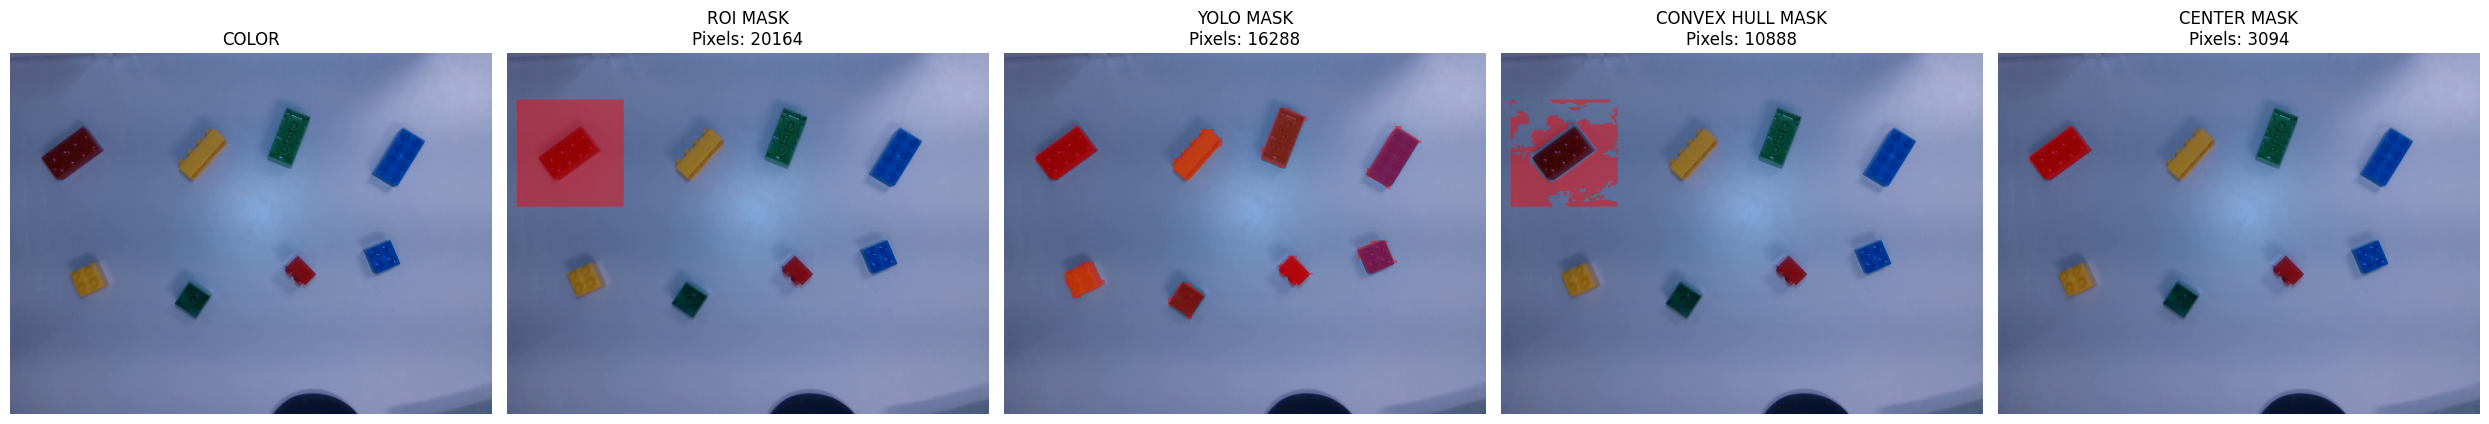

In [181]:
visualize_yolo_roi_hull_analysis(
    color_img_bgr=color_filtered,
    roi_mask=roi_mask,
    yolo_mask=yolo_union_mask,
    hull_mask=floor_candidate_mask,
    center_mask=selected_yolo_mask_roi
)

<hr style="height: 5px; background-color: #39FF14; border: none;">

In [182]:
def visualize_yolo_detections_overlay(
    color_img_bgr,
    detections,
    conf_threshold=0.25,
    alpha=0.45
):
    """
    YOLO detections 전체 mask를 color image 위에 overlay한다.
    """

    if color_img_bgr is None:
        raise ValueError("color_img_bgr가 None입니다.")

    if detections is None:
        raise ValueError("detections가 None입니다.")

    color_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)
    overlay = color_rgb.copy()

    used_count = 0

    for det in detections:
        conf = float(det.get("confidence", 0.0))

        if conf < conf_threshold:
            continue

        mask = det.get("mask", None)

        if mask is None:
            continue

        mask_bool = mask > 0

        overlay[mask_bool] = (
            overlay[mask_bool] * (1.0 - alpha) +
            np.array([255, 0, 0]) * alpha
        ).astype(np.uint8)

        used_count += 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].imshow(color_rgb)
    axes[0].set_title("COLOR")
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title(f"YOLO DETECTIONS OVERLAY\nUsed detections: {used_count}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

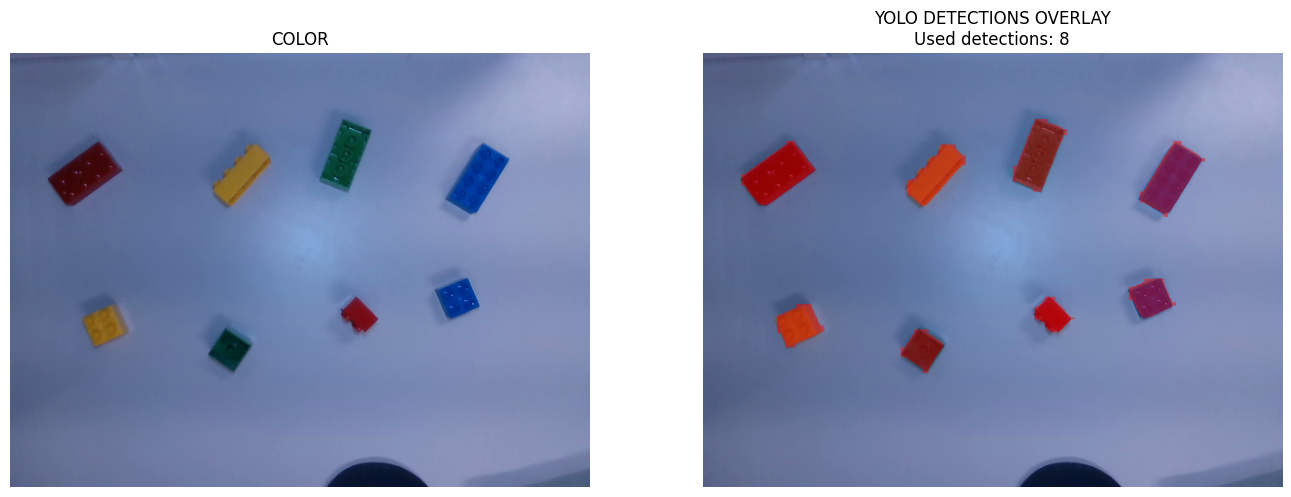

In [183]:
visualize_yolo_detections_overlay(
    color_img_bgr=color_filtered,
    detections=detections,
    conf_threshold=0.25,
    alpha=0.45
)

In [184]:
def visualize_selected_detection(
    color_img_bgr,
    selected_det,
    alpha=0.45
):
    """
    선택된 YOLO detection 하나의 bbox와 mask를 시각화한다.
    """

    if color_img_bgr is None:
        raise ValueError("color_img_bgr가 None입니다.")

    if selected_det is None:
        raise ValueError("selected_det가 None입니다.")

    color_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

    mask = selected_det["mask"]
    bbox = selected_det["bbox_xyxy"]
    class_name = selected_det["class_name"]
    confidence = selected_det["confidence"]

    overlay = color_rgb.copy()
    mask_bool = mask > 0

    overlay[mask_bool] = (
        overlay[mask_bool] * (1.0 - alpha) +
        np.array([255, 0, 0]) * alpha
    ).astype(np.uint8)

    x1, y1, x2, y2 = [int(round(v)) for v in bbox]

    overlay_bgr = cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    cv2.rectangle(overlay_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
    overlay = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].imshow(color_rgb)
    axes[0].set_title("COLOR")
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title(
        f"SELECTED DETECTION\n"
        f"{class_name}, conf={confidence:.3f}, pixels={np.count_nonzero(mask)}"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

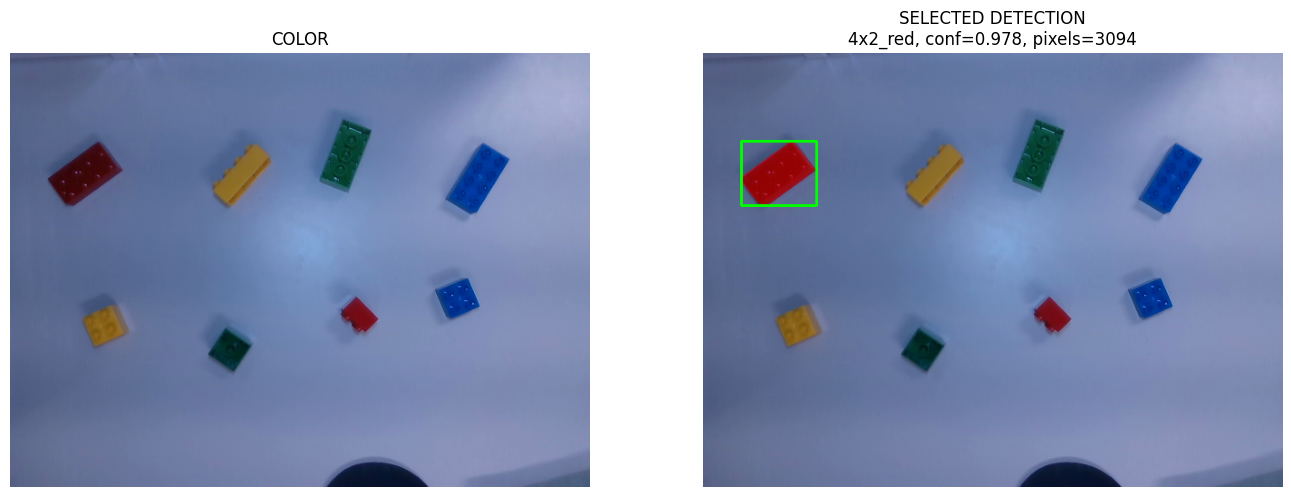

In [185]:
visualize_selected_detection(
    color_img_bgr=color_filtered,
    selected_det=selected_det,
    alpha=0.45
)

In [186]:
def visualize_roi_and_floor_candidate(
    color_img_bgr,
    roi_mask,
    yolo_union_mask,
    floor_candidate_mask,
    alpha=0.45
):
    """
    ROI, YOLO union mask, floor candidate mask를 각각 시각화한다.
    """

    if color_img_bgr is None:
        raise ValueError("color_img_bgr가 None입니다.")

    color_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

    items = [
        ("ROI MASK", roi_mask),
        ("YOLO UNION MASK", yolo_union_mask),
        ("FLOOR CANDIDATE MASK", floor_candidate_mask),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    axes[0].imshow(color_rgb)
    axes[0].set_title("COLOR")
    axes[0].axis("off")

    for i, (title, mask) in enumerate(items):
        overlay = color_rgb.copy()

        mask_bool = mask > 0

        overlay[mask_bool] = (
            overlay[mask_bool] * (1.0 - alpha) +
            np.array([255, 0, 0]) * alpha
        ).astype(np.uint8)

        axes[i + 1].imshow(overlay)
        axes[i + 1].set_title(f"{title}\nPixels: {np.count_nonzero(mask)}")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()

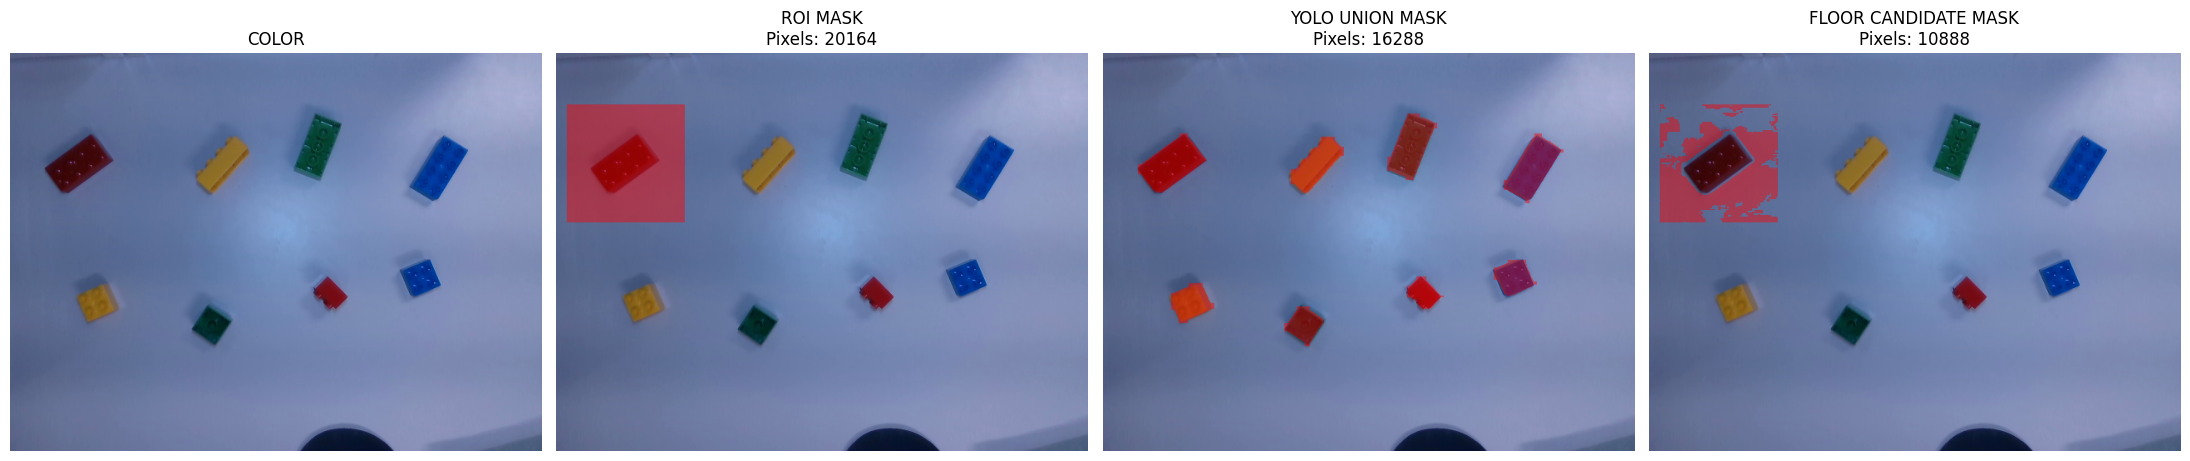

In [187]:
visualize_roi_and_floor_candidate(
    color_img_bgr=color_filtered,
    roi_mask=roi_mask,
    yolo_union_mask=yolo_union_mask,
    floor_candidate_mask=floor_candidate_mask,
    alpha=0.45
)

In [188]:
def visualize_height_map_and_selected_mask(
    color_img_bgr,
    height_map,
    height_valid_mask,
    selected_mask,
    top_candidate_mask=None,
    alpha=0.45
):
    """
    floor height map과 selected YOLO mask, top candidate mask를 시각화한다.
    """

    if color_img_bgr is None:
        raise ValueError("color_img_bgr가 None입니다.")

    color_rgb = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 4 if top_candidate_mask is not None else 3, figsize=(24, 5))

    axes[0].imshow(color_rgb)
    axes[0].set_title("COLOR")
    axes[0].axis("off")

    valid_bool = height_valid_mask > 0
    height_vis = height_map.copy()

    if np.count_nonzero(valid_bool) > 0:
        h_min = np.percentile(height_vis[valid_bool], 1)
        h_max = np.percentile(height_vis[valid_bool], 99)

        if h_max <= h_min:
            h_max = h_min + 1.0

        height_clip = np.clip(height_vis, h_min, h_max)

        height_norm = np.zeros_like(height_vis, dtype=np.uint8)
        height_norm[valid_bool] = (
            (height_clip[valid_bool] - h_min) / (h_max - h_min) * 255
        ).astype(np.uint8)

        height_color = cv2.applyColorMap(height_norm, cv2.COLORMAP_JET)
        height_color[~valid_bool] = (0, 0, 0)
        height_color = cv2.cvtColor(height_color, cv2.COLOR_BGR2RGB)

        axes[1].imshow(height_color)
        axes[1].set_title(f"FLOOR HEIGHT MAP\nRange: {h_min:.1f} ~ {h_max:.1f} mm")
        axes[1].axis("off")
    else:
        axes[1].imshow(np.zeros_like(height_map), cmap="gray")
        axes[1].set_title("HEIGHT MAP EMPTY")
        axes[1].axis("off")

    def overlay_mask(mask):
        overlay = color_rgb.copy()
        mask_bool = mask > 0

        overlay[mask_bool] = (
            overlay[mask_bool] * (1.0 - alpha) +
            np.array([255, 0, 0]) * alpha
        ).astype(np.uint8)

        return overlay

    axes[2].imshow(overlay_mask(selected_mask))
    axes[2].set_title(f"SELECTED YOLO MASK\nPixels: {np.count_nonzero(selected_mask)}")
    axes[2].axis("off")

    if top_candidate_mask is not None:
        axes[3].imshow(overlay_mask(top_candidate_mask))
        axes[3].set_title(f"TOP CANDIDATE MASK\nPixels: {np.count_nonzero(top_candidate_mask)}")
        axes[3].axis("off")

    plt.tight_layout()
    plt.show()

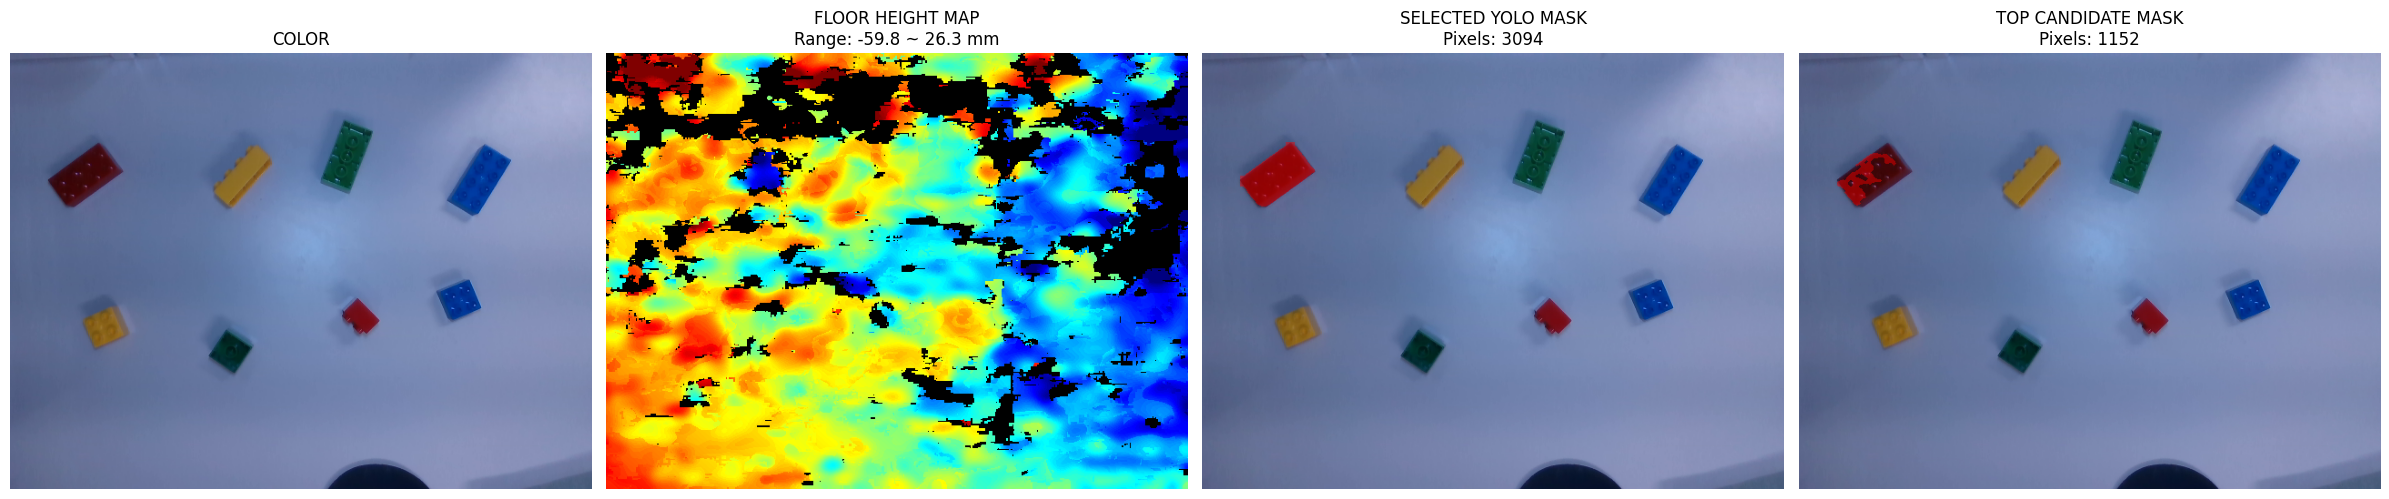

In [189]:
visualize_height_map_and_selected_mask(
    color_img_bgr=color_filtered,
    height_map=floor_height_map,
    height_valid_mask=floor_height_valid_mask,
    selected_mask=selected_yolo_mask_roi,
    top_candidate_mask=top_candidate_mask,
    alpha=0.45
)